# 🧪 Lab — 2D Perception: Detection · Segmentation · Keypoints
**AICB · Computer Vision · Track 4 · Ngày 18** — 120 phút — Google Colab (GPU T4)

> 🏭 **Bài toán xuyên suốt.** Camera ở cổng nhà máy cần biết: **có bao nhiêu người**, **ai không đội mũ bảo hộ**, và **có ai vừa ngã**.
> Trong 120 phút bạn tự tay dựng từng mảnh của câu trả lời đó.

| Phần | Bạn làm gì | Mảnh ghép cho camera cổng | ⏱ |
|---|---|---|---|
| 0 | Setup, tải sẵn model và dữ liệu | — | 10' |
| 1 · Detection | Tự viết IoU + NMS, so sánh YOLO26 có NMS và NMS-free | Đếm người | 35' |
| 2 · Segmentation | Tự viết mask IoU, polygon ↔ mask, auto-label bằng SAM 2.1 | Tạo nhãn nhanh cho class mới (mũ bảo hộ) | 30' |
| 3 · Keypoints | Tự viết OKS và góc khớp, dựng luật "ngã" | Phát hiện người ngã | 25' |
| 4 · Fine-tune | Sửa `flip_idx`, train YOLO26n-pose trên tiger-pose, phân tích lỗi | Dạy model một đối tượng mới | 20' |

### Cách làm việc với notebook này
| Ký hiệu | Ý nghĩa |
|---|---|
| 🔮 **Dự đoán** | Tự nhẩm kết quả *trước khi* chạy ô. Không chấm điểm, nhưng đây là lúc bạn học được nhiều nhất. |
| 🧩 **TODO** | Điền code vào chỗ có `...`. Mỗi chỗ chỉ 1 dòng. Chạy ô là có phản hồi ✅ / ❌ ngay bên dưới. |
| 💡 **Gợi ý** | Bấm để mở. Kẹt quá 3 phút thì mở, đừng ngại. |
| 🚦 **Chốt** | Ô `gate(...)` cuối mỗi mục TODO. Chưa xong thì notebook dừng ở đó. |
| 🛟 **Phao** | Hết giờ của mục mà chưa xong: sửa thành `gate("...", lifeline=True)` để mượn bản thư viện và đi tiếp. Hàm mượn phao không được tính điểm. |
| ❓ **Câu hỏi** | Trả lời 2–4 câu vào chuỗi `Q1 = """ ... """` ngay bên dưới (12 câu cả bài). |
| ⭐ | Nâng cao, làm nếu còn thời gian hoặc về nhà. |

### Nộp gì?
Notebook đã **Restart & Run All** không lỗi + thư mục `submission/` do ô cuối cùng tạo ra (gồm `ket_qua.json` và `autolabel/bus.txt`). Chi tiết ở cuối notebook và trong `README.md`.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VinUni-AI20k/Track04-Day18-2D-perception-detection-segmentation-keypoints/blob/main/lab_2d_perception_student.ipynb)

---
## Phần 0 — Setup (10')
1. `Runtime → Change runtime type → T4 GPU`.
2. Chạy lần lượt 5 ô dưới đây. Ô thứ tư tải khoảng 0,8 GB weights và dữ liệu; trong lúc chờ hãy đọc trước mục 1A.

In [1]:
%pip install -q "ultralytics==8.4.171"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc, json, math, random, shutil, time, warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import ultralytics
import yaml
from scipy.optimize import linear_sum_assignment
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes, draw_keypoints, draw_segmentation_masks
from ultralytics import SAM, YOLO

warnings.filterwarnings("ignore")
torch.manual_seed(0); np.random.seed(0); random.seed(0)

GPU = torch.cuda.is_available()
DEVICE = "cuda" if GPU else "cpu"
ASSETS = Path(ultralytics.__file__).parent / "assets"          # 2 ảnh mẫu đi kèm package, không cần tải
IMG_BUS, IMG_ZIDANE = str(ASSETS / "bus.jpg"), str(ASSETS / "zidane.jpg")

print(f"torch {torch.__version__} | torchvision {torchvision.__version__} | ultralytics {ultralytics.__version__} | device = {DEVICE}")
if not GPU:
    print("⚠️  Không thấy GPU. Notebook vẫn chạy được, nhưng Phần 4 sẽ tự giảm epochs/imgsz và kết quả sẽ kém. Hãy bật T4.")

torch 2.14.0+cu126 | torchvision 0.29.1+cu126 | ultralytics 8.4.171 | device = cuda


In [3]:
# @title 🔧 Hàm tiện ích + bộ kiểm tra — chỉ cần chạy, không cần đọc
import inspect, re
from IPython.display import Markdown, display

G = globals()
PROGRESS = {}                                   # tên deliverable → "ok" | "lifeline"
PLACEHOLDER = "(viết câu trả lời của bạn ở đây)"
SECTIONS = {"1B": ["box_iou", "nms", "batched_nms"], "2B": ["mask_iou", "polygon_to_mask", "mask_to_yolo_seg"],
            "3B": ["oks"], "3C": ["joint_angle"], "4A": ["FLIP_IDX"]}
SIDE_COLORS = {"right": "#d62728", "left": "#1f77b4", "mid": "#ff7f0e"}


# ───────────────────────── hiển thị ─────────────────────────
def show(*images, titles=None, ncols=None, size=5.0):
    """Hiển thị nhiều ảnh cạnh nhau. Nhận torch uint8 (C,H,W) hoặc numpy (H,W,C) RGB."""
    n = len(images); ncols = ncols or n; nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for i, img in enumerate(images):
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu()
            img = img.permute(1, 2, 0).numpy() if img.ndim == 3 else img.numpy()
        axes.flat[i].imshow(img)
        if titles:
            axes.flat[i].set_title(titles[i], fontsize=11)
    plt.tight_layout(); plt.show()


def bgr_to_u8(img_bgr):
    """numpy BGR (cv2, Results.plot()) → torch uint8 RGB (3,H,W)."""
    return torch.from_numpy(np.ascontiguousarray(img_bgr[..., ::-1])).permute(2, 0, 1)


def show_table(rows, title=None):
    """In list[dict] thành bảng Markdown."""
    if not rows:
        return
    cols = list(rows[0].keys())
    fmt = lambda v: f"{v:.3f}" if isinstance(v, float) else str(v)
    md = (f"**{title}**\n\n" if title else "") + "| " + " | ".join(cols) + " |\n|" + "---|" * len(cols) + "\n"
    md += "\n".join("| " + " | ".join(fmt(r[c]) for c in cols) + " |" for r in rows)
    display(Markdown(md))


def draw_det(img, boxes, cls, conf, color, names):
    labels = [f"{names[int(k)]} {p:.2f}" for k, p in zip(cls, conf)]
    return draw_bounding_boxes(img, boxes, labels, width=3, colors=color, font_size=22)


def side_of(name):
    return "right" if name.startswith("right_") else "left" if name.startswith("left_") else "mid"


def plot_kpts(ax, img_rgb, kpts, names, title="", marker="o", size=70):
    """Vẽ keypoint lên ảnh: đỏ = right_*, xanh = left_*, cam = trục giữa."""
    ax.imshow(img_rgb); ax.axis("off"); ax.set_title(title, fontsize=10)
    ax.scatter(kpts[:, 0], kpts[:, 1], s=size, c=[SIDE_COLORS[side_of(n)] for n in names],
               edgecolors="white", linewidths=1.5, marker=marker)


# ───────────────────────── khung kiểm tra ─────────────────────────
class LabStop(AssertionError):
    """Dừng 'Run all' bằng một thông báo gọn, không in traceback."""

    def _render_traceback_(self):
        return [str(self)]


def _todo_left(fn):
    """Đếm số chỗ `...` còn lại trong mã nguồn của một hàm."""
    try:
        src = inspect.getsource(fn)
    except Exception:
        return 0
    return sum(bool(re.search(r"(^|=|return)\s*\.\.\.\s*(#.*)?$", ln.strip())) for ln in src.splitlines())


def _run(name, steps, quiet=False):
    """steps: list[(mô tả, hàm thử)] — hàm thử trả về None nếu đạt, hoặc một chuỗi gợi ý nếu sai."""
    if getattr(G.get(name), "_lifeline", False):
        PROGRESS[name] = "lifeline"
        if not quiet:
            print(f"🛟 {name}: đang dùng bản thư viện (phao). Muốn được tính điểm, hãy hoàn thành rồi chạy lại ô TODO.")
        return
    left = _todo_left(G.get(name)) if callable(G.get(name)) else 0
    if left:
        PROGRESS.pop(name, None)
        if not quiet:
            print(f"❌ {name} — còn {left} chỗ `...` chưa điền. Điền hết rồi chạy lại ô này.")
        return
    for desc, test in steps:
        try:
            hint = test()
        except Exception as e:
            txt = f"{type(e).__name__}: {e}"
            hint = "vẫn còn chỗ `...` chưa điền." if "ellipsis" in txt.lower() else f"code báo lỗi → {txt}"
        if hint:
            PROGRESS.pop(name, None)
            if not quiet:
                print(f"❌ {name} — {desc}\n   ↳ {hint}")
            return
    PROGRESS[name] = "ok"
    if not quiet:
        print(f"✅ {name} đạt ({len(steps)} phép thử)")


def _not_tensor(out, what="hàm"):
    if out is Ellipsis or out is None:
        return f"{what} đang trả về `{out}` — còn chỗ chưa điền."
    if not isinstance(out, torch.Tensor):
        return f"{what} phải trả về torch.Tensor, đang trả về {type(out).__name__}."


def _toy_boxes():
    return torch.tensor([[0., 0., 10., 10.], [5., 0., 15., 10.], [20., 20., 30., 30.]])   # A, B, C


def _rand_boxes(n, seed, size=640):
    g = torch.Generator().manual_seed(seed)
    xy = torch.rand(n, 2, generator=g) * size
    wh = torch.rand(n, 2, generator=g) * size / 4 + 4
    return torch.cat([xy, xy + wh], 1)


# ───────────────────────── 1B ─────────────────────────
def check_box_iou(quiet=False):
    from torchvision.ops import box_iou as ref
    t = _toy_boxes()
    f = lambda *a: G["box_iou"](*a)

    def shape():
        out = f(t, t[:2])
        if _not_tensor(out):
            return _not_tensor(out)
        if tuple(out.shape) != (3, 2):
            return f"IoU của 3 box × 2 box phải có shape (3, 2), bạn ra {tuple(out.shape)}. Xem lại broadcast: area_a[:, None] + area_b[None, :]."

    def same():
        d = f(t, t).diagonal()
        if not torch.allclose(d, torch.ones(3), atol=1e-5):
            return f"IoU của một box với chính nó phải = 1, bạn ra {[round(v, 3) for v in d.tolist()]}. Kiểm tra Bước 1 (diện tích) và Bước 4 (hợp = |A| + |B| − giao)."

    def disjoint():
        v = float(f(t[:1], t[2:])[0, 0])
        if abs(v) > 1e-6:
            return f"A và C không chạm nhau nên IoU phải = 0, bạn ra {v:.4f}. Ở Bước 3, (rb − lt) âm theo cả hai chiều thì tích lại dương → thêm .clamp(min=0)."

    def toy():
        v = float(f(t[:1], t[1:2])[0, 0])
        if abs(v - 1 / 3) > 1e-4:
            return f"IoU(A, B) phải = 50/150 = 0.3333, bạn ra {v:.4f}. Bước 2: góc trên-trái lấy max, góc dưới-phải lấy min."

    def rand():
        a, b = _rand_boxes(50, 1), _rand_boxes(70, 2)
        if not torch.allclose(f(a, b), ref(a, b), atol=1e-5):
            return "chưa khớp torchvision trên 50 × 70 box ngẫu nhiên — xem lại cả 4 bước."

    _run("box_iou", [("shape (N, M)", shape), ("box với chính nó", same), ("ví dụ A–B tính tay", toy),
                     ("hai box rời nhau", disjoint), ("so với torchvision", rand)], quiet)


def check_nms(quiet=False):
    from torchvision.ops import nms as ref
    t = _toy_boxes()
    f = lambda *a: G["nms"](*a)

    def needs():
        if PROGRESS.get("box_iou") is None:
            return "nms dùng box_iou — hãy làm cho box_iou đạt ✅ trước."

    def toy_strict():
        out = f(t, torch.tensor([0.9, 0.8, 0.7]), 0.3)
        if _not_tensor(out):
            return _not_tensor(out)
        got = out.tolist()
        if got == [0, 1, 2]:
            return "ngưỡng 0.3: B (IoU 0.333 với A) phải bị loại, nhưng bạn giữ cả 3. Bước 2 chưa lọc: order = rest[ious <= iou_thr]."
        if got in ([0], [0, 1]):
            return f"ngưỡng 0.3: phải giữ A và C, loại B; bạn ra {got}. Kiểm tra chiều so sánh ở Bước 2: giữ box có IoU <= ngưỡng, loại box có IoU > ngưỡng."
        if got != [0, 2]:
            return f"ngưỡng 0.3: kỳ vọng giữ [0, 2] (A và C), bạn ra {got}."

    def toy_loose():
        got = f(t, torch.tensor([0.9, 0.8, 0.7]), 0.5).tolist()
        if got != [0, 1, 2]:
            return f"ngưỡng 0.5: IoU(A, B) = 0.333 không vượt ngưỡng nên giữ cả 3, bạn ra {got}."

    def boundary():
        got = f(torch.tensor([[0., 0, 10, 10], [0, 0, 10, 5]]), torch.tensor([0.9, 0.8]), 0.5).tolist()
        if got != [0, 1]:
            return f"hai box có IoU đúng bằng 0.5, ngưỡng 0.5: chỉ loại khi IoU > ngưỡng nên phải giữ cả hai; bạn ra {got}. Bước 2 dùng <=, không phải <."

    def order():
        out = f(torch.tensor([[0., 0, 5, 5], [10, 10, 15, 15], [20, 20, 25, 25]]), torch.tensor([0.1, 0.9, 0.5]), 0.5)
        if out.dtype != torch.long or out.tolist() != [1, 2, 0]:
            return f"kết quả phải là LongTensor chỉ số, xếp theo score giảm dần: [1, 2, 0]; bạn ra {out.tolist()} ({out.dtype})."

    def rand():
        b = _rand_boxes(300, 3); s = torch.rand(300, generator=torch.Generator().manual_seed(4))
        for thr in (0.3, 0.5, 0.7):
            if not torch.equal(f(b, s, thr), ref(b, s, thr)):
                return f"chưa khớp torchvision trên 300 box ngẫu nhiên ở ngưỡng {thr}."

    _run("nms", [("cần box_iou", needs), ("ví dụ A, B, C — ngưỡng 0.3", toy_strict), ("ví dụ A, B, C — ngưỡng 0.5", toy_loose),
                 ("IoU đúng bằng ngưỡng", boundary), ("thứ tự + kiểu dữ liệu", order), ("so với torchvision", rand)], quiet)


def check_batched_nms(quiet=False):
    from torchvision.ops import batched_nms as ref
    t = _toy_boxes()
    f = lambda *a: G["batched_nms"](*a)

    def needs():
        if PROGRESS.get("nms") is None:
            return "batched_nms dùng nms — hãy làm cho nms đạt ✅ trước."

    def diff_class():
        out = f(t[:2], torch.tensor([0.9, 0.8]), torch.tensor([0, 1]), 0.3)
        if _not_tensor(out):
            return _not_tensor(out)
        if out.tolist() != [0, 1]:
            return f"A và B khác class nên phải giữ cả hai dù IoU = 0.333 > 0.3; bạn ra {out.tolist()}. Offset đã cộng vào toạ độ chưa?"

    def same_class():
        got = f(t[:2], torch.tensor([0.9, 0.8]), torch.tensor([1, 1]), 0.3).tolist()
        if got != [0]:
            return f"A và B cùng class thì B phải bị loại; bạn ra {got}. Offset phải bằng nhau cho các box cùng class."

    def rand():
        b = _rand_boxes(300, 3); s = torch.rand(300, generator=torch.Generator().manual_seed(4))
        c = torch.randint(0, 3, (300,), generator=torch.Generator().manual_seed(5))
        for thr in (0.3, 0.5, 0.7):
            if not torch.equal(f(b, s, c, thr), ref(b, s, c, thr)):
                return f"chưa khớp torchvision trên 300 box, 3 class ở ngưỡng {thr}."

    _run("batched_nms", [("cần nms", needs), ("hai box khác class", diff_class), ("hai box cùng class", same_class),
                         ("so với torchvision", rand)], quiet)


def check_average_precision(quiet=False):
    f = lambda *a: G["average_precision"](*a)
    tp = np.array([1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0]); conf = np.linspace(0.95, 0.25, 15)

    def perfect():
        v = f(np.array([1, 1]), np.array([0.9, 0.8]), 2)
        if v is Ellipsis or v is None:
            return "hàm đang trả về `...`."
        if abs(v - 1.0) > 1e-6:
            return f"2 dự đoán đều TP, 2 GT → AP phải = 1.0; bạn ra {v:.4f}."

    def nothing():
        v = f(np.array([0, 0, 0]), np.array([0.9, 0.8, 0.7]), 5)
        if abs(v) > 1e-6:
            return f"không có TP nào → AP phải = 0; bạn ra {v:.4f}."

    def shuffled():
        p = np.random.default_rng(0).permutation(15)
        if abs(f(tp[p], conf[p], 10) - f(tp, conf, 10)) > 1e-9:
            return "AP đổi khi xáo thứ tự đầu vào — tp phải được sắp theo conf giảm dần trước khi cộng dồn."

    def slide():
        v = f(tp, conf, 10)
        if abs(v - 0.535) > 0.01:
            wrong = float(np.mean(np.cumsum(tp) / np.arange(1, 16)))
            extra = " Có vẻ bạn chưa dùng envelope (Bước 2)." if abs(v - wrong) < 0.05 else ""
            return f"ví dụ trên slide (10 GT, 15 dự đoán) phải ra AP ≈ 0.535; bạn ra {v:.4f}.{extra}"

    _run("average_precision", [("mọi dự đoán đều đúng", perfect), ("không có TP", nothing),
                               ("không phụ thuộc thứ tự đầu vào", shuffled), ("ví dụ trên slide", slide)], quiet)


# ───────────────────────── 2B ─────────────────────────
def _fill(poly, h, w):
    m = np.zeros((h, w), np.uint8)
    cv2.fillPoly(m, [np.round(poly).astype(np.int32)], 1)
    return m.astype(bool)


def _np_iou(a, b):
    return float((a & b).sum() / max((a | b).sum(), 1))


def _parse_seg_line(line, h, w):
    parts = line.split()
    return int(parts[0]), np.array(parts[1:], dtype=float).reshape(-1, 2) * [w, h]


def check_mask_iou(quiet=False):
    f = lambda *a: G["mask_iou"](*a)
    A = torch.zeros(1, 100, 100, dtype=torch.bool); A[0, :50, :50] = True
    B = torch.zeros(1, 100, 100, dtype=torch.bool); B[0, 25:75, 25:75] = True

    def shape():
        out = f(torch.cat([A, B, A]), torch.cat([A, B]))
        if _not_tensor(out):
            return _not_tensor(out)
        if tuple(out.shape) != (3, 2):
            return f"3 mask × 2 mask phải ra ma trận (3, 2), bạn ra {tuple(out.shape)}. inter = a @ b.T; union = area_a[:, None] + area_b[None, :] − inter."

    def toy():
        v = float(f(A, B)[0, 0])
        if abs(v - 625 / 4375) > 1e-5:
            return f"hai hình vuông 50×50 lệch nhau 25 px: giao 625, hợp 4375 → IoU = 0.1429; bạn ra {v:.4f}."

    def same():
        d = f(torch.cat([A, B]), torch.cat([A, B])).diagonal()
        if not torch.allclose(d.float(), torch.ones(2), atol=1e-5):
            return f"IoU của mask với chính nó phải = 1, bạn ra {[round(v, 3) for v in d.tolist()]}."

    def rand():
        g = torch.Generator().manual_seed(0)
        m1 = torch.rand(4, 32, 40, generator=g) > 0.6; m2 = torch.rand(6, 32, 40, generator=g) > 0.4
        ref = torch.stack([torch.stack([(a & b).sum() / (a | b).sum() for b in m2]) for a in m1])
        if not torch.allclose(f(m1, m2).float(), ref.float(), atol=1e-5):
            return "chưa khớp cách tính bằng vòng lặp trên mask ngẫu nhiên."

    _run("mask_iou", [("shape (N, M)", shape), ("ví dụ hai hình vuông", toy), ("mask với chính nó", same), ("so với vòng lặp", rand)], quiet)


def check_polygon_to_mask(quiet=False):
    f = lambda *a: G["polygon_to_mask"](*a)

    def square():
        m = f(np.array([[10, 10], [60, 10], [60, 60], [10, 60]]), 100, 100)
        if not isinstance(m, np.ndarray) or m.dtype != bool or m.shape != (100, 100):
            return f"phải trả về numpy bool (100, 100); bạn ra {type(m).__name__} {getattr(m, 'dtype', '')} {getattr(m, 'shape', '')}."
        if m.sum() == 0:
            return "mask rỗng — bạn đã gọi cv2.fillPoly(mask, [pts], 1) chưa?"
        if abs(int(m.sum()) - 51 * 51) > 110:
            return f"hình vuông cạnh 50 phải tô khoảng 2601 pixel, bạn tô {int(m.sum())}."

    def wide():
        m = f(np.array([[10, 10], [90, 10], [10, 40]]), 50, 100)
        if m.shape != (50, 100) or not m[15, 30] or m[45, 90]:
            return "tam giác trên ảnh H=50, W=100 bị sai vị trí — toạ độ polygon là (x, y), mask là [y, x]."

    _run("polygon_to_mask", [("hình vuông", square), ("ảnh không vuông", wide)], quiet)


def check_mask_to_yolo_seg(quiet=False):
    f = lambda *a, **k: G["mask_to_yolo_seg"](*a, **k)
    H, W = 200, 300
    circle = np.zeros((H, W), np.uint8); cv2.circle(circle, (150, 100), 60, 1, -1); circle = circle.astype(bool)

    def fmt():
        line = f(circle, 3)
        if not isinstance(line, str) or not line.strip():
            return "phải trả về một chuỗi 'class x1 y1 x2 y2 ...' (đang rỗng hoặc sai kiểu)."
        parts = line.split()
        if parts[0] != "3":
            return f"token đầu phải là class id '3', bạn ra '{parts[0]}'."
        if (len(parts) - 1) % 2 or len(parts) < 7:
            return f"sau class id phải là các cặp (x, y), ít nhất 3 đỉnh; bạn có {len(parts) - 1} số."

    def normalized():
        vals = np.array(f(circle, 3).split()[1:], dtype=float)
        if vals.max() > 1.0 + 1e-6 or vals.min() < 0:
            return f"toạ độ phải nằm trong [0, 1], bạn có giá trị tới {vals.max():.2f}. Bước 3: x chia cho W, y chia cho H."

    def roundtrip():
        _, poly = _parse_seg_line(f(circle, 3), H, W)
        v = _np_iou(circle, _fill(poly, H, W))
        if v < 0.95:
            return f"vẽ lại polygon thì chỉ trùng {v:.2f} với mask gốc (cần > 0.95). Hay gặp: chia x cho H và y cho W (ngược)."

    def largest():
        for corner in ((5, 5), (190, 290)):
            m = circle.copy(); m[corner[0]:corner[0] + 5, corner[1]:corner[1] + 5] = True
            _, poly = _parse_seg_line(f(m, 0), H, W)
            if _np_iou(circle, _fill(poly, H, W)) < 0.9:
                return "mask có thêm một mảnh vụn 5×5 thì bạn lại lấy mảnh vụn. Bước 1: chọn contour có diện tích lớn nhất, không phải contours[0]."

    _run("mask_to_yolo_seg", [("định dạng dòng nhãn", fmt), ("toạ độ chuẩn hoá", normalized),
                              ("mask → polygon → mask", roundtrip), ("chọn mảnh lớn nhất", largest)], quiet)


def check_autolabel(path="autolabel/bus.txt", ref_masks=None, quiet=False):
    """Kiểm tra file nhãn YOLO-seg: định dạng, khoảng giá trị, và độ khớp với mask gốc."""
    p, problem = Path(path), None
    if not p.exists():
        problem = f"chưa có file {path}."
    else:
        lines = [l for l in p.read_text().splitlines() if l.strip()]
        if not lines:
            problem = "file rỗng."
        elif ref_masks is not None and len(lines) != len(ref_masks):
            problem = f"file có {len(lines)} dòng nhưng có {len(ref_masks)} mask."
        for k, line in enumerate(lines if not problem else []):
            parts = line.split()
            vals = np.array(parts[1:], dtype=float)
            if not parts[0].isdigit() or len(vals) % 2 or len(vals) < 6:
                problem = f"dòng {k + 1} sai định dạng 'class x1 y1 x2 y2 ...'."
            elif vals.min() < 0 or vals.max() > 1:
                problem = f"dòng {k + 1} có toạ độ ngoài [0, 1]."
            elif ref_masks is not None:
                m = ref_masks[k].numpy() if isinstance(ref_masks[k], torch.Tensor) else ref_masks[k]
                v = _np_iou(m, _fill(vals.reshape(-1, 2) * [m.shape[1], m.shape[0]], *m.shape))
                if v < 0.85:
                    problem = f"dòng {k + 1}: polygon chỉ trùng {v:.2f} với mask SAM."
            if problem:
                break
    if problem:
        PROGRESS.pop("autolabel", None)
        if not quiet:
            print(f"❌ autolabel — {problem}")
    else:
        PROGRESS["autolabel"] = "ok"
        if not quiet:
            print(f"✅ {path} hợp lệ: {len(lines)} object, toạ độ chuẩn hoá, polygon khớp mask.")


# ───────────────────────── 3B, 3C ─────────────────────────
def check_oks(quiet=False):
    from ultralytics.utils.metrics import OKS_SIGMA, kpt_iou
    f = lambda *a, **k: G["oks"](*a, **k)
    g = torch.Generator().manual_seed(0)
    gt = torch.rand(17, 2, generator=g) * 200; pred = gt + torch.randn(17, 2, generator=g) * 6
    vis = torch.rand(17, generator=g) > 0.2; area = 150 * 300.0
    sig = np.asarray(OKS_SIGMA, dtype=float)
    d2 = ((gt - pred) ** 2).sum(1).numpy(); k = 2 * sig; v = vis.numpy()

    def ref(vv):
        return kpt_iou(torch.cat([gt, vv[:, None].float() * 2], 1)[None], torch.cat([pred, torch.ones(17, 1)], 1)[None],
                       torch.tensor([area]), OKS_SIGMA)[0, 0].item()

    def perfect():
        out = f(gt.numpy(), gt.numpy(), area)
        if out is Ellipsis or out is None:
            return "hàm đang trả về `...`."
        if abs(float(out) - 1.0) > 1e-6:
            return f"dự đoán trùng khít GT thì OKS phải = 1, bạn ra {float(out):.4f}."

    def all_visible():
        mine = float(f(gt.numpy(), pred.numpy(), area)); want = ref(torch.ones(17, dtype=torch.bool))
        if abs(mine - want) > 1e-4:
            wrong = {
                "thiếu hệ số 2 ở mẫu số: phải là 2 · s² · k²": np.exp(-d2 / (area * k ** 2)).mean(),
                "đang dùng d thay vì d² (quên bình phương khoảng cách)": np.exp(-np.sqrt(d2) / (2 * area * k ** 2)).mean(),
                "đang bình phương area: s² CHÍNH LÀ area": np.exp(-d2 / (2 * area ** 2 * k ** 2)).mean(),
                "đang dùng σ thay cho k = 2σ": np.exp(-d2 / (2 * area * sig ** 2)).mean(),
            }
            why = next((msg for msg, val in wrong.items() if abs(mine - val) < 1e-4), "xem lại công thức ở Bước 1 và 3")
            return f"OKS = {mine:.4f}, Ultralytics ra {want:.4f} → {why}."

    def visibility():
        mine = float(f(gt.numpy(), pred.numpy(), area, vis=v)); want = ref(vis)
        if abs(mine - want) > 1e-4:
            return f"có {int((~v).sum())} keypoint không có nhãn: OKS = {mine:.4f}, kỳ vọng {want:.4f}. Bước 4 chỉ lấy trung bình trên keypoint có vis = True: sim[vis].mean()."

    _run("oks", [("dự đoán hoàn hảo", perfect), ("so với Ultralytics", all_visible), ("bỏ qua keypoint không có nhãn", visibility)], quiet)


def check_joint_angle(quiet=False):
    f = lambda *a: G["joint_angle"](*a)

    def cases():
        for (a, b, c), want in [(((0, 1), (0, 0), (1, 0)), 90), (((-1, 0), (0, 0), (1, 0)), 180), (((2, 2), (0, 0), (5, 0)), 45), (((3, 0), (0, 0), (7, 0)), 0)]:
            got = f(a, b, c)
            if got is Ellipsis or got is None:
                return "hàm đang trả về `...`."
            if abs(float(got) - want) > 1e-3:
                extra = " Hai vector phải cùng xuất phát từ b: a − b và c − b." if want in (90, 45) else ""
                return f"joint_angle({a}, {b}, {c}) phải = {want}°, bạn ra {float(got):.2f}°.{extra}"

    def tensors():
        got = f(torch.tensor([0., 1.]), torch.tensor([0., 0.]), torch.tensor([1., 0.]))
        if abs(float(got) - 90) > 1e-3:
            return "hàm phải nhận được cả torch.Tensor (keypoint từ model)."

    _run("joint_angle", [("4 góc tính tay", cases), ("đầu vào là tensor", tensors)], quiet)


# ───────────────────────── 4A ─────────────────────────
def _mirror_name(n):
    return n.replace("left_", "\0").replace("right_", "left_").replace("\0", "right_")


def check_flip_idx(quiet=False):
    names = G.get("TIGER_KPTS"); fi = G.get("FLIP_IDX")
    if fi is not None and fi is G.get("_FLIP_LIFELINE"):
        PROGRESS["FLIP_IDX"] = "lifeline"
        if not quiet:
            print("🛟 FLIP_IDX: đang dùng phao.")
        return

    def perm():
        if not isinstance(fi, (list, tuple)) or sorted(fi) != list(range(12)):
            return "FLIP_IDX phải là một hoán vị của 0..11 (list 12 số nguyên, không lặp)."

    def identity():
        if list(fi) == list(range(12)):
            return "FLIP_IDX vẫn là [0, 1, …, 11] — chưa hoán đổi cặp left_* ↔ right_* nào."

    def involution():
        if any(fi[fi[i]] != i for i in range(12)):
            return "lật hai lần phải về như cũ: nếu FLIP_IDX[4] = 7 thì FLIP_IDX[7] phải = 4."

    def by_name():
        bad = [f"{i} ({names[i]}) → {fi[i]} ({names[fi[i]]})" for i in range(12) if _mirror_name(names[i]) != names[fi[i]]]
        if bad:
            return "sai ở: " + "; ".join(bad[:4]) + ". Mỗi left_X phải trỏ tới right_X cùng tên, điểm trục giữa trỏ về chính nó."

    _run("FLIP_IDX", [("là hoán vị của 0..11", perm), ("đã sửa", identity), ("đối xứng", involution), ("đúng theo tên keypoint", by_name)], quiet)


CHECKS = {"box_iou": check_box_iou, "nms": check_nms, "batched_nms": check_batched_nms, "mask_iou": check_mask_iou,
          "polygon_to_mask": check_polygon_to_mask, "mask_to_yolo_seg": check_mask_to_yolo_seg, "oks": check_oks,
          "joint_angle": check_joint_angle, "FLIP_IDX": check_flip_idx}


# ───────────────────────── phao: bản thư viện ─────────────────────────
def _lifeline(fn):
    wrapped = lambda *a, **k: fn(*a, **k)
    wrapped._lifeline = True
    return wrapped


def _ll_mask_iou(m1, m2):
    from ultralytics.utils.metrics import mask_iou as lib
    return lib(m1.flatten(1).float(), m2.flatten(1).float())


def _ll_polygon_to_mask(poly, h, w):
    from ultralytics.data.utils import polygon2mask
    return polygon2mask((h, w), [np.asarray(poly, dtype=np.float32).reshape(-1)], color=1, downsample_ratio=1).astype(bool)


def _ll_mask_to_yolo_seg(mask, cls_id, simplify=0.002):
    from ultralytics.utils.ops import masks2segments
    seg = masks2segments(torch.from_numpy(mask.astype(np.uint8))[None], strategy="largest")[0]
    if len(seg) < 3:
        return ""
    seg = cv2.approxPolyDP(seg.astype(np.float32).reshape(-1, 1, 2), simplify * cv2.arcLength(seg.astype(np.float32), True), True).reshape(-1, 2)
    return f"{cls_id} " + " ".join(f"{v:.6f}" for v in (seg / [mask.shape[1], mask.shape[0]]).flatten())


def _ll_oks(kpt_gt, kpt_pred, area, sigmas=None, vis=None):
    from ultralytics.utils.metrics import OKS_SIGMA, kpt_iou
    gt, pr = torch.as_tensor(np.asarray(kpt_gt), dtype=torch.float32), torch.as_tensor(np.asarray(kpt_pred), dtype=torch.float32)
    v = torch.ones(len(gt)) if vis is None else torch.as_tensor(np.asarray(vis)).float()
    sig = OKS_SIGMA if sigmas is None else np.asarray(sigmas, dtype=np.float32)
    return kpt_iou(torch.cat([gt, v[:, None] * 2], 1)[None], torch.cat([pr, torch.ones(len(pr), 1)], 1)[None],
                   torch.tensor([float(area)]), sig)[0, 0].item()


def _ll_joint_angle(a, b, c):
    a, b, c = (np.asarray(p, dtype=float) for p in (a, b, c))
    d = abs(math.degrees(math.atan2(a[1] - b[1], a[0] - b[0]) - math.atan2(c[1] - b[1], c[0] - b[0]))) % 360
    return min(d, 360 - d)


def _get_lifeline(name):
    if name in ("box_iou", "nms", "batched_nms"):
        import torchvision.ops as tvo
        return _lifeline({"box_iou": lambda a, b: tvo.box_iou(a, b),
                          "nms": lambda boxes, scores, iou_thr=0.5: tvo.nms(boxes, scores, iou_thr),
                          "batched_nms": lambda boxes, scores, classes, iou_thr=0.5: tvo.batched_nms(boxes, scores, classes, iou_thr)}[name])
    if name == "FLIP_IDX":
        names = G["TIGER_KPTS"]
        G["_FLIP_LIFELINE"] = [names.index(_mirror_name(n)) for n in names]
        return G["_FLIP_LIFELINE"]
    return _lifeline({"mask_iou": _ll_mask_iou, "polygon_to_mask": _ll_polygon_to_mask, "mask_to_yolo_seg": _ll_mask_to_yolo_seg,
                      "oks": _ll_oks, "joint_angle": _ll_joint_angle}[name])


def gate(section, lifeline=False):
    """🚦 Chốt một mục TODO: đủ ✅ thì đi tiếp, thiếu thì dừng (hoặc mượn phao nếu lifeline=True)."""
    names = SECTIONS[section]
    for n in names:
        CHECKS[n](quiet=True)
    missing = [n for n in names if PROGRESS.get(n) is None]
    if missing and lifeline:
        for n in missing:
            G[n] = _get_lifeline(n); PROGRESS[n] = "lifeline"
        missing = []
    if missing:
        raise LabStop(f"⛔ Mục {section} chưa xong: {', '.join(missing)}.\n"
                      f"   • Đọc thông báo ❌ ngay dưới ô TODO tương ứng và mở 💡 gợi ý.\n"
                      f"   • Hết giờ của mục này? Sửa ô này thành  gate(\"{section}\", lifeline=True)  để mượn bản thư viện và đi tiếp.")
    borrowed = [n for n in names if PROGRESS.get(n) == "lifeline"]
    if borrowed:
        print(f"🛟 Mục {section}: đang mượn phao cho {', '.join(borrowed)}. Các ô sau chạy được, nhưng những phần này chưa được tính là hoàn thành.")
    else:
        print(f"✅ Mục {section} xong: {', '.join(names)}. Đi tiếp!")


# ───────────────────────── tổng kết ─────────────────────────
def _answered(q):
    txt = str(G.get(q, "")).strip()
    return PLACEHOLDER not in txt and len(txt) >= 30


def final_report(download=False):
    """In checklist deliverable, ghi submission/ket_qua.json và đóng gói submission.zip."""
    for n, c in CHECKS.items():
        if n in G:
            c(quiet=True)
    if "masks_sam" in G:
        check_autolabel(ref_masks=G["masks_sam"], quiet=True)
    if "average_precision" in G:
        check_average_precision(quiet=True)
    icon = {"ok": "✅", "lifeline": "🛟 (mượn phao)", None: "❌"}
    print("── 6 hàm tự cài đặt ──")
    for n in ["box_iou", "nms", "batched_nms", "mask_iou", "oks", "joint_angle"]:
        print(f"  {icon[PROGRESS.get(n)]:<3} {n}")
    print("── Phần còn lại ──")
    others = {
        "polygon_to_mask + mask_to_yolo_seg": "ok" if all(PROGRESS.get(n) == "ok" for n in ("polygon_to_mask", "mask_to_yolo_seg"))
        else "lifeline" if all(PROGRESS.get(n) for n in ("polygon_to_mask", "mask_to_yolo_seg")) else None,
        "Bảng latency (1C)": "ok" if len(G.get("LATENCY", [])) == 4 else None,
        "autolabel/bus.txt (2C)": PROGRESS.get("autolabel"),
        "FLIP_IDX (4A)": PROGRESS.get("FLIP_IDX"),
        "Bảng mAP tiger-pose (4B)": "ok" if G.get("RESULT_4B") else None,
    }
    for label, st in others.items():
        print(f"  {icon[st]:<3} {label}")
    answered = [q for q in (f"Q{i}" for i in range(1, 13)) if _answered(q)]
    todo_q = [f"Q{i}" for i in range(1, 13) if f"Q{i}" not in answered]
    print(f"  {'✅' if not todo_q else '❌'}  Câu hỏi: {len(answered)}/12" + (f" — còn thiếu {', '.join(todo_q)}" if todo_q else ""))
    print("── ⭐ Nâng cao (không bắt buộc) ──")
    print(f"  {icon[PROGRESS.get('average_precision')]:<3} average_precision (1D)")
    print(f"  {'✅' if G.get('RESULT_4C') else '—'}  Thí nghiệm val lật gương (4C)")

    out = Path("submission"); (out / "autolabel").mkdir(parents=True, exist_ok=True)
    if Path("autolabel/bus.txt").exists():
        shutil.copy("autolabel/bus.txt", out / "autolabel" / "bus.txt")
    report = {"progress": PROGRESS, "latency": G.get("LATENCY"), "result_4b": G.get("RESULT_4B"), "result_4c": G.get("RESULT_4C"),
              "answers": {f"Q{i}": str(G.get(f"Q{i}", "")).strip() for i in range(1, 13)},
              "env": {"device": DEVICE, "torch": torch.__version__, "ultralytics": ultralytics.__version__}}
    (out / "ket_qua.json").write_text(json.dumps(report, ensure_ascii=False, indent=2, default=float), encoding="utf-8")
    shutil.make_archive("submission", "zip", root_dir=".", base_dir="submission")
    print("\n📦 Đã tạo thư mục submission/ và file submission.zip (ket_qua.json + autolabel/bus.txt).")
    if download:
        try:
            from google.colab import files
            files.download("submission.zip")
        except ImportError:
            print("   (không chạy trên Colab — tự lấy file submission.zip trong thư mục làm việc)")


print("🔧 Sẵn sàng: show, show_table, gate, final_report và các hàm check_*.")

🔧 Sẵn sàng: show, show_table, gate, final_report và các hàm check_*.


In [4]:
# Tải trước toàn bộ weights + dataset (khoảng 0,8 GB) để các phần sau không phải chờ.
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights, KeypointRCNN_ResNet50_FPN_Weights, MaskRCNN_ResNet50_FPN_V2_Weights
from ultralytics.data.utils import check_det_dataset
from ultralytics.utils.downloads import attempt_download_asset

t0 = time.time()
for w in (FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT, MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT, KeypointRCNN_ResNet50_FPN_Weights.DEFAULT):
    _ = w.get_state_dict(progress=False); del _
    print("✓ torchvision:", w.url.split("/")[-1])
for name in ("yolo26n.pt", "yolo26n-seg.pt", "yolo26n-sem.pt", "yolo26n-pose.pt", "sam2.1_t.pt"):
    attempt_download_asset(name)
    print("✓ ultralytics:", name)
TIGER = check_det_dataset("tiger-pose.yaml")                     # dataset cho Phần 4 (49.8 MB)
print("✓ dataset    : tiger-pose →", TIGER["path"])
print(f"Xong trong {time.time() - t0:.0f} giây.")

✓ torchvision:

 fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


✓ torchvision: maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth
✓ torchvision: keypointrcnn_resnet50_fpn_coco-fc266e95.pth
✓ ultralytics: yolo26n.pt
✓ ultralytics: yolo26n-seg.pt
✓ ultralytics: yolo26n-sem.pt
✓ ultralytics: yolo26n-pose.pt
✓ ultralytics: sam2.1_t.pt
✓ dataset    : tiger-pose → D:\Project-AI20K\datasets\tiger-pose
Xong trong 0 giây.


bus.jpg: (3, 1080, 810) | zidane.jpg: (3, 720, 1280)


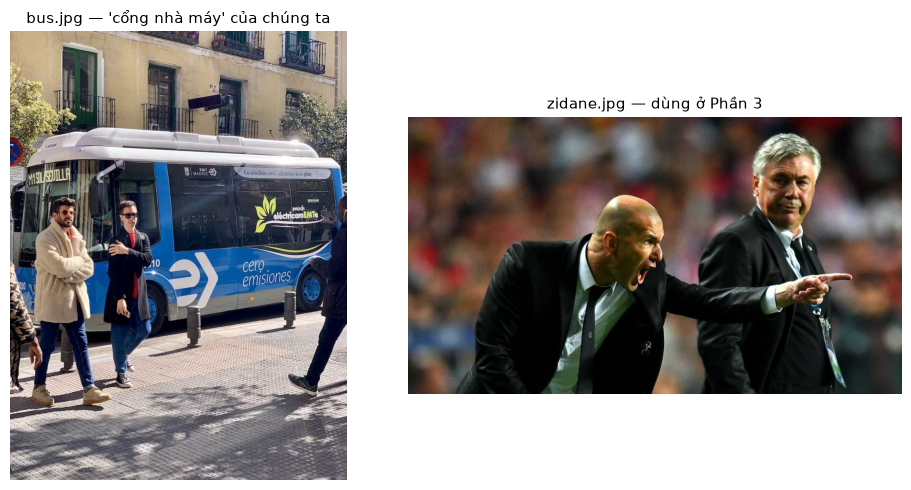

In [5]:
img_bus, img_zidane = read_image(IMG_BUS), read_image(IMG_ZIDANE)        # torch.uint8, (3, H, W), RGB
print("bus.jpg:", tuple(img_bus.shape), "| zidane.jpg:", tuple(img_zidane.shape))
show(img_bus, img_zidane, titles=["bus.jpg — 'cổng nhà máy' của chúng ta", "zidane.jpg — dùng ở Phần 3"])

---
## Phần 1 — Object Detection (35')
🏭 **Mảnh ghép 1: đếm người ở cổng.** Detector trả về một *tập* box có kích thước không biết trước. Để đếm đúng, mỗi người phải ứng với **đúng một** box, và đó là việc của NMS (hoặc của head one-to-one).

### 1A. Đọc output của detector như một tensor — 7'
Chạy 3 ô dưới và chú ý **shape**. Chưa cần code gì.

Output của 1 ảnh: {'boxes': (29, 4), 'labels': (29,), 'scores': (29,)}  ← N × (box xyxy, class, score)


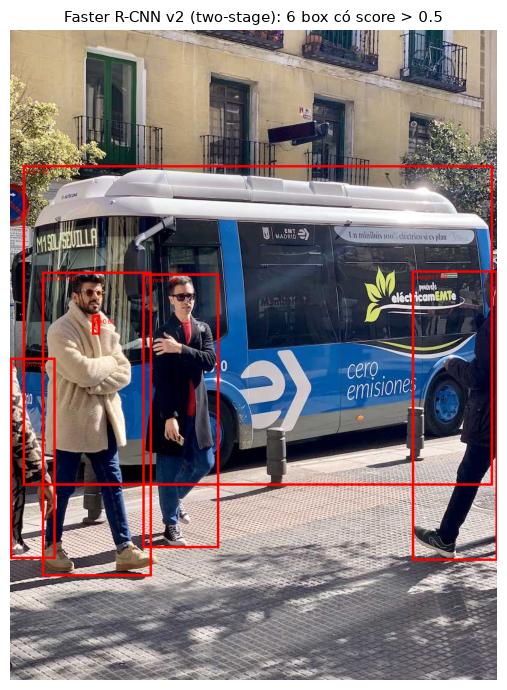

Hai lần NMS bên trong model: RPN (IoU 0.7, giữ 1000 proposal) → RoI head (IoU 0.5, score ≥ 0.05)


In [6]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2

w_det = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT                # COCO box AP 46.7
frcnn = fasterrcnn_resnet50_fpn_v2(weights=w_det).eval().to(DEVICE)
COCO_TV = w_det.meta["categories"]                                 # 91 tên class của torchvision

with torch.inference_mode():
    out = frcnn([w_det.transforms()(img_bus).to(DEVICE)])[0]       # vào: list ảnh float [0,1] · ra: list dict
out = {k: v.cpu() for k, v in out.items()}
print("Output của 1 ảnh:", {k: tuple(v.shape) for k, v in out.items()}, " ← N × (box xyxy, class, score)")

keep = out["scores"] > 0.5
frcnn_boxes, frcnn_labels, frcnn_scores = out["boxes"][keep], out["labels"][keep], out["scores"][keep]
tags = [f"{COCO_TV[c]} {s:.2f}" for c, s in zip(frcnn_labels, frcnn_scores)]
show(draw_bounding_boxes(img_bus, frcnn_boxes, tags, width=4, colors="red", font_size=26),
     titles=[f"Faster R-CNN v2 (two-stage): {int(keep.sum())} box có score > 0.5"], size=7)
print(f"Hai lần NMS bên trong model: RPN (IoU {frcnn.rpn.nms_thresh}, giữ {frcnn.rpn.post_nms_top_n()} proposal) "
      f"→ RoI head (IoU {frcnn.roi_heads.nms_thresh}, score ≥ {frcnn.roi_heads.score_thresh})")

🔮 **Dự đoán.** YOLO26 dự đoán trên 3 tầng feature có stride 8, 16, 32, mỗi vị trí một dự đoán.
Với ảnh vào 640×640 thì có bao nhiêu dự đoán thô? Còn với `bus.jpg` sau khi letterbox về 640×480? Nhẩm xong rồi chạy ô dưới.

In [7]:
from ultralytics.data.augment import LetterBox

yolo = YOLO("yolo26n.pt")
NAMES = yolo.names
net = yolo.model.eval()                                            # nn.Module nằm bên trong


def raw_forward(h, w):
    """Cho một ảnh rỗng (h, w) đi qua mạng, trả về output thô trước mọi bước lọc."""
    x = torch.zeros(1, 3, h, w, device=next(net.parameters()).device)
    with torch.inference_mode():
        decoded, heads = net(x)
    return decoded, heads


decoded, heads = raw_forward(640, 640)
print("640×640 →", tuple(decoded.shape), "= (batch, 4 toạ độ + 80 class, số dự đoán)")
for name in ("one2many", "one2one"):
    print(f"   head {name}: boxes {tuple(heads[name]['boxes'].shape)} · scores {tuple(heads[name]['scores'].shape)}"
          f" · lưới 3 tầng {[tuple(f.shape[-2:]) for f in heads[name]['feats']]}")

lb = LetterBox((640, 640), auto=True, stride=32)(image=cv2.imread(IMG_BUS))
print(f"bus.jpg {tuple(img_bus.shape[-2:])} → letterbox {lb.shape[:2]} →", tuple(raw_forward(*lb.shape[:2])[0].shape))

640×640 → (1, 84, 8400) = (batch, 4 toạ độ + 80 class, số dự đoán)
   head one2many: boxes (1, 4, 8400) · scores (1, 80, 8400) · lưới 3 tầng [(80, 80), (40, 40), (20, 20)]
   head one2one: boxes (1, 4, 8400) · scores (1, 80, 8400) · lưới 3 tầng [(80, 80), (40, 40), (20, 20)]
bus.jpg (1080, 810) → letterbox (640, 480) → (1, 84, 6300)


**Box 'person' trên ảnh 810×1080**

| Quy ước | Giá trị |
|---|---|
| xyxy — torchvision, Pascal VOC | [53, 402, 236, 908] |
| xywh — COCO json | [53, 402, 182, 506] |
| cxcywh chuẩn hoá — YOLO .txt | [0.178, 0.606, 0.225, 0.468] |

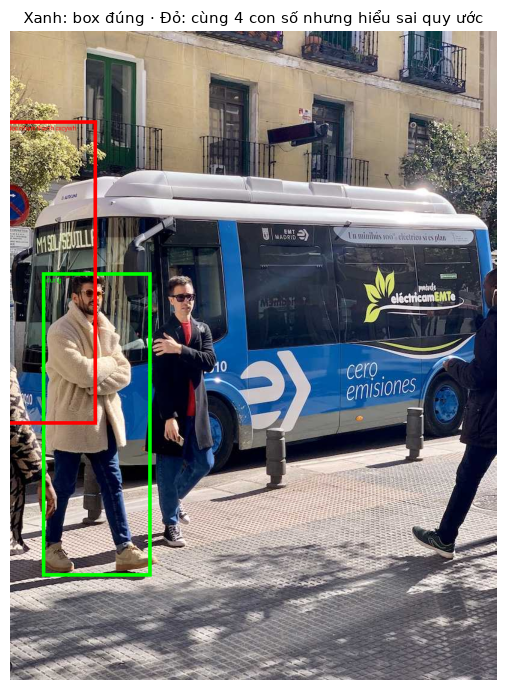

In [8]:
# Một box, ba cách viết — và bug kinh điển khi nhầm chúng
H, W = img_bus.shape[-2:]
x1, y1, x2, y2 = frcnn_boxes[0].tolist()                           # box điểm cao nhất, dạng xyxy
xywh = [x1, y1, x2 - x1, y2 - y1]                                  # COCO json: góc trên-trái + kích thước (pixel)
cxcywh_n = [(x1 + x2) / 2 / W, (y1 + y2) / 2 / H, (x2 - x1) / W, (y2 - y1) / H]   # nhãn YOLO .txt: tâm + kích thước, chia cho W, H
show_table([
    {"Quy ước": "xyxy — torchvision, Pascal VOC", "Giá trị": str([round(v) for v in (x1, y1, x2, y2)])},
    {"Quy ước": "xywh — COCO json", "Giá trị": str([round(v) for v in xywh])},
    {"Quy ước": "cxcywh chuẩn hoá — YOLO .txt", "Giá trị": str([round(v, 3) for v in cxcywh_n])},
], title=f"Box '{COCO_TV[frcnn_labels[0]]}' trên ảnh {W}×{H}")

bx, by, bw, bh = xywh                                              # dữ liệu là xywh ...
wrong = [bx - bw / 2, by - bh / 2, bx + bw / 2, by + bh / 2]       # ... nhưng bị đọc như thể (bx, by) là TÂM
show(draw_bounding_boxes(img_bus, torch.tensor([[x1, y1, x2, y2], wrong]), ["dung", "xywh doc nham thanh cxcywh"],
                         colors=["lime", "red"], width=6, font_size=26),
     titles=["Xanh: box đúng · Đỏ: cùng 4 con số nhưng hiểu sai quy ước"], size=7)

❓ **Q1.** (a) `bus.jpg` sau letterbox là 640×480. Có bao nhiêu dự đoán thô, và vì sao ít hơn 8 400?
(b) Bạn nhận một file nhãn mà khi vẽ lên ảnh, mọi box đều lệch sang **phải và xuống dưới** đúng nửa kích thước của nó. Nhãn gốc ở quy ước nào và đã bị đọc như quy ước nào?

In [9]:
Q1 = """
(a) Với bus.jpg sau letterbox (kích thước 640×480), YOLO26 dự đoán trên 3 tầng feature map tương ứng với stride 8, 16, 32:
- Tầng stride 8: (640/8) × (480/8) = 80 × 60 = 4 800 dự đoán.
- Tầng stride 16: (640/16) × (480/16) = 40 × 30 = 1 200 dự đoán.
- Tầng stride 32: (640/32) × (480/32) = 20 × 15 = 300 dự đoán.
Tổng cộng có 4 800 + 1 200 + 300 = 6 300 dự đoán thô. Con số này ít hơn 8 400 (của ảnh vuông 640×640) vì chiều rộng ảnh giảm từ 640 xuống 480 pixel (tỉ lệ 480/640 = 3/4, và 8 400 × 3/4 = 6 300). Số lượng ô lưới dự đoán trên các tầng feature map tỉ lệ thuận trực tiếp với diện tích ảnh đầu vào.

(b) Nhãn gốc ở quy ước cxcywh (tâm box và kích thước) nhưng đã bị đọc/hiểu nhầm theo quy ước xywh (góc trên-trái và kích thước). Khi đọc nhầm toạ độ tâm (cx, cy) thành góc trên-trái (x1, y1), góc trên-trái thực tế bị dịch chuyển từ (cx - w/2, cy - h/2) thành (cx, cy), khiến toàn bộ bounding box bị lệch sang phải một đoạn w/2 và lệch xuống dưới một đoạn h/2 đúng bằng nửa kích thước box.
"""


### 1B. 🧩 Tự cài đặt IoU và NMS — 15'

$$\mathrm{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}=\frac{|A\cap B|}{|A|+|B|-|A\cap B|}$$

Ví dụ dùng suốt mục này — ba box dạng `xyxy`:

| Box | Toạ độ | Diện tích |
|---|---|---|
| A | (0, 0, 10, 10) | 100 |
| B | (5, 0, 15, 10) | 100 |
| C | (20, 20, 30, 30) | 100 |

🔮 **Dự đoán.** IoU(A, B) = ? IoU(A, C) = ? (A và B chồng nhau một dải rộng 5, cao 10.)

**Bước 1/3 — `box_iou`.** Điền 4 chỗ `...`. Không dùng `torchvision.ops`.

In [10]:
def box_iou(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """a: (N,4), b: (M,4), định dạng xyxy → ma trận IoU (N,M)."""
    # Bước 1 — diện tích từng box = (x2 − x1) · (y2 − y1)
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])            # (N,)
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])            # (M,)   🧩
    # Bước 2 — hình chữ nhật giao: góc trên-trái lấy max, góc dưới-phải lấy min.
    #          a[:, None, :2] có shape (N,1,2), b[None, :, :2] có shape (1,M,2) → broadcast thành (N,M,2)
    lt = torch.max(a[:, None, :2], b[None, :, :2])                # (N,M,2)
    rb = torch.min(a[:, None, 2:], b[None, :, 2:])                # (N,M,2) 🧩
    # Bước 3 — (rộng, cao) của phần giao. Hai box không chạm nhau thì phải ra 0, không được âm.
    wh = (rb - lt).clamp(min=0)                                   # (N,M,2) 🧩
    inter = wh[..., 0] * wh[..., 1]                               # (N,M)
    # Bước 4 — IoU = giao / hợp, với hợp = |A| + |B| − giao
    return inter / (area_a[:, None] + area_b[None, :] - inter)    # 🧩


check_box_iou()


✅ box_iou đạt (5 phép thử)


<details><summary>💡 Gợi ý 1 — Bước 1 và 2</summary>

`area_b` viết y hệt `area_a`, đổi `a` thành `b`. `rb` viết y hệt `lt`, đổi `torch.max` thành `torch.min` và `:2` thành `2:`.
</details>
<details><summary>💡 Gợi ý 2 — Bước 3</summary>

`(rb - lt)` cho (rộng, cao). Khi hai box rời nhau, cả hai số đều âm và tích của chúng lại dương. Chặn bằng `.clamp(min=0)`.
</details>
<details><summary>💡 Gợi ý 3 — Bước 4</summary>

`area_a` có shape (N,), `area_b` có shape (M,). Để cộng thành (N,M): `area_a[:, None] + area_b[None, :]`. Rồi trừ `inter` và lấy `inter / (...)`.
</details>

**Bước 2/3 — `nms`.** Greedy NMS: giữ box điểm cao nhất, loại mọi box còn lại có IoU **>** ngưỡng với nó, lặp lại.

🔮 **Dự đoán.** Với score A = 0.9, B = 0.8, C = 0.7: ngưỡng 0.3 giữ những box nào? Ngưỡng 0.5 thì sao?

In [11]:
def nms(boxes: torch.Tensor, scores: torch.Tensor, iou_thr: float = 0.5) -> torch.Tensor:
    """Greedy NMS. Trả về chỉ số (LongTensor) các box được giữ, theo thứ tự score giảm dần."""
    order = scores.argsort(descending=True)                       # chỉ số box, điểm cao → thấp
    keep = []
    while order.numel() > 0:
        i = order[0]                                              # box điểm cao nhất còn lại → giữ
        keep.append(int(i))
        assert len(keep) <= len(boxes), "order không ngắn lại → vòng lặp vô hạn. Xem lại Bước 2."
        rest = order[1:]                                          # chỉ số các box còn lại
        # Bước 1 — IoU giữa box i và từng box trong rest. Dùng box_iou của bạn; boxes[i][None] có shape (1,4).
        ious = box_iou(boxes[i][None], boxes[rest])[0]            # (len(rest),)  🧩
        # Bước 2 — chỉ giữ lại trong hàng chờ những box có IoU <= iou_thr (IoU > ngưỡng nghĩa là duplicate của box i)
        order = rest[ious <= iou_thr]                             # 🧩
    return torch.tensor(keep, dtype=torch.long)


check_nms()


✅ nms đạt (6 phép thử)


<details><summary>💡 Gợi ý — <code>nms</code></summary>

Bước 1: `box_iou(boxes[i][None], boxes[rest])` trả về ma trận (1, len(rest)); lấy hàng đầu bằng `[0]`.
Bước 2: `rest[ious <= iou_thr]` — dùng mask boolean để lọc chính `rest`.
</details>

**Bước 3/3 — `batched_nms`.** Người đứng trước xe buýt có IoU cao với xe buýt nhưng **không** phải duplicate. NMS chỉ nên so các box *cùng class*.
Mẹo: dịch toàn bộ box của class `c` đi một đoạn `c × (toạ độ lớn nhất + 1)`. Khi đó box khác class không bao giờ chạm nhau, và chỉ cần gọi `nms` thường một lần.

In [12]:
def batched_nms(boxes: torch.Tensor, scores: torch.Tensor, classes: torch.Tensor, iou_thr: float = 0.5) -> torch.Tensor:
    """Class-aware NMS: chỉ loại duplicate giữa các box CÙNG class."""
    # Bước 1 — độ dịch của từng box: class id × (toạ độ lớn nhất + 1). classes.to(boxes) đổi class id sang cùng kiểu float.
    offset = classes.to(boxes) * (boxes.max() + 1)                # (N,)  🧩
    # Bước 2 — cộng offset vào cả 4 toạ độ (offset[:, None] có shape (N,1)) rồi gọi nms của bạn
    return nms(boxes + offset[:, None], scores, iou_thr)          # 🧩


check_batched_nms()


✅ batched_nms đạt (4 phép thử)


<details><summary>💡 Gợi ý — <code>batched_nms</code></summary>

`offset = classes.to(boxes) * (boxes.max() + 1)`, rồi `return nms(boxes + offset[:, None], scores, iou_thr)`.
Chỉ số trả về vẫn là chỉ số của `boxes` gốc vì ta không đổi thứ tự, chỉ dịch toạ độ.
</details>

In [13]:
gate("1B")        # 🚦 hết 15 phút mà chưa xong? → gate("1B", lifeline=True)

✅ Mục 1B xong: box_iou, nms, batched_nms. Đi tiếp!


### 1C. YOLO26: one-to-many + NMS và one-to-one (NMS-free) — 8'
YOLO26 train **hai head** trên cùng backbone:
- **one-to-many**: mỗi object được gán cho nhiều vị trí → tín hiệu học dày, nhưng output có duplicate → **cần NMS**;
- **one-to-one**: mỗi object đúng một dự đoán (như Hungarian matching của DETR) → **không cần NMS**.

Trong Ultralytics: mặc định dùng one-to-many + NMS, còn `nms=False` chuyển sang head one-to-one. Đặt `iou=1.0` thì NMS gần như không loại box nào, nên ta nhìn thấy duplicate.
Ta dùng **hai object riêng** (`yolo` và `yolo_e2e`) vì một object đã chuyển sang `nms=False` sẽ giữ nguyên head one-to-one cho các lần gọi sau.

🔮 **Dự đoán.** Ảnh có 4 người và 1 xe buýt. Head one-to-many ở conf ≥ 0.25 sẽ cho khoảng bao nhiêu box trước NMS: 5, 15, hay 50?

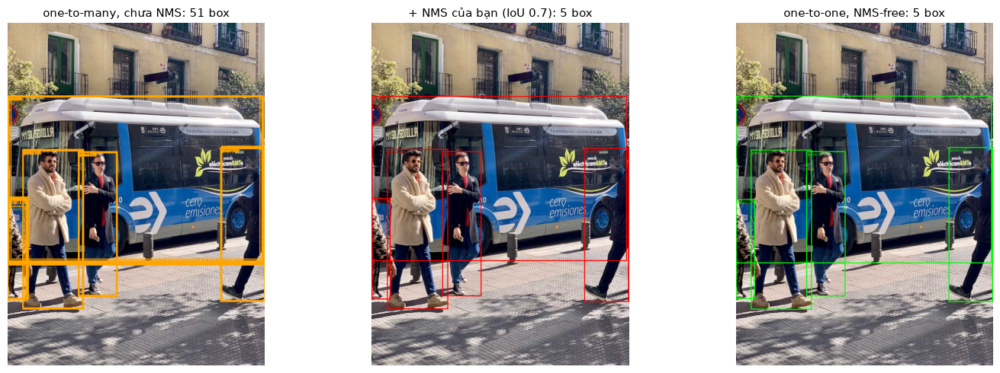

NMS của bạn giữ 5 box · NMS của Ultralytics giữ 5 box ✅ khớp
🏭 Camera cổng đếm được: 4 người, 1 xe buýt.


In [14]:
CONF = 0.25
yolo_e2e = YOLO("yolo26n.pt")                                            # cùng weights, nhưng luôn gọi với nms=False
r_raw = yolo.predict(IMG_BUS, conf=CONF, iou=1.0, verbose=False)[0]      # one-to-many, NMS gần như tắt
r_nms = yolo.predict(IMG_BUS, conf=CONF, iou=0.7, verbose=False)[0]      # one-to-many + NMS của Ultralytics
r_e2e = yolo_e2e.predict(IMG_BUS, conf=CONF, nms=False, verbose=False)[0]   # one-to-one, không NMS

b, s, c = r_raw.boxes.xyxy.cpu(), r_raw.boxes.conf.cpu(), r_raw.boxes.cls.cpu()
keep_mine = batched_nms(b, s, c, iou_thr=0.7)                            # ← NMS của BẠN

show(draw_det(img_bus, b, c, s, "orange", NAMES),
     draw_det(img_bus, b[keep_mine], c[keep_mine], s[keep_mine], "red", NAMES),
     draw_det(img_bus, r_e2e.boxes.xyxy.cpu(), r_e2e.boxes.cls.cpu(), r_e2e.boxes.conf.cpu(), "lime", NAMES),
     titles=[f"one-to-many, chưa NMS: {len(b)} box", f"+ NMS của bạn (IoU 0.7): {len(keep_mine)} box",
             f"one-to-one, NMS-free: {len(r_e2e.boxes)} box"])
print(f"NMS của bạn giữ {len(keep_mine)} box · NMS của Ultralytics giữ {len(r_nms.boxes)} box", "✅ khớp" if len(keep_mine) == len(r_nms.boxes) else "❌ lệch — xem lại 1B")
print(f"🏭 Camera cổng đếm được: {int((r_e2e.boxes.cls == 0).sum())} người, {int((r_e2e.boxes.cls == 5).sum())} xe buýt.")

Giờ đo **latency từng giai đoạn** ở hai mức confidence: 0.25 (lúc triển khai) và 0.001 (lúc tính mAP).

🔮 **Dự đoán.** Cột nào (preprocess, inference, postprocess) sẽ khác nhau nhiều nhất giữa hai head? Ở mức conf nào?

In [15]:
def bench(model, n=30, **kw):
    """Thời gian trung bình (ms) của từng giai đoạn trên bus.jpg, lấy từ Results.speed."""
    model.predict(IMG_BUS, verbose=False, **kw)                          # warm-up
    acc = {"preprocess": 0.0, "inference": 0.0, "postprocess": 0.0}
    for _ in range(n):
        r = model.predict(IMG_BUS, verbose=False, **kw)[0]
        for k in acc:
            acc[k] += r.speed[k] / n
    return {f"{k} (ms)": round(v, 2) for k, v in acc.items()} | {"số box": len(r.boxes)}


LATENCY = [
    {"Cấu hình": "one-to-many + NMS, conf 0.25"} | bench(yolo, conf=0.25, iou=0.7),
    {"Cấu hình": "one-to-many + NMS, conf 0.001"} | bench(yolo, conf=0.001, iou=0.7),
    {"Cấu hình": "one-to-one NMS-free, conf 0.25"} | bench(yolo_e2e, conf=0.25, nms=False),
    {"Cấu hình": "one-to-one NMS-free, conf 0.001"} | bench(yolo_e2e, conf=0.001, nms=False),
]
show_table(LATENCY, title=f"Latency YOLO26n trên {DEVICE} (trung bình 30 lần)")

**Latency YOLO26n trên cuda (trung bình 30 lần)**

| Cấu hình | preprocess (ms) | inference (ms) | postprocess (ms) | số box |
|---|---|---|---|---|
| one-to-many + NMS, conf 0.25 | 1.910 | 18.900 | 2.740 | 5 |
| one-to-many + NMS, conf 0.001 | 2.200 | 19.970 | 3.020 | 202 |
| one-to-one NMS-free, conf 0.25 | 2.010 | 22.250 | 0.970 | 5 |
| one-to-one NMS-free, conf 0.001 | 1.920 | 17.130 | 0.890 | 204 |

❓ **Q2.** Nhìn vào bảng của bạn: cột nào thay đổi nhiều nhất giữa hai head, và ở mức conf nào? Giải thích vì sao lợi ích của NMS-free rõ hơn khi conf thấp, khi cảnh đông, và khi chạy trên CPU/NPU.

In [16]:
Q2 = """
- Cột thay đổi nhiều nhất giữa hai head là postprocess (ms), đặc biệt rõ rệt ở mức conf thấp 0.001 (lúc đánh giá mAP). Ở conf 0.25 (lúc triển khai), số box ít nên chênh lệch nhỏ hơn, nhưng ở conf 0.001, postprocess của one-to-many tăng vọt trong khi one-to-one giữ nguyên gần như bằng 0 (< 1 ms).
- Giải thích:
  + Khi conf thấp (0.001) hoặc khi cảnh rất đông đối tượng (crowded scene), hàng ngàn candidate box vượt qua ngưỡng score và được đẩy vào NMS. Thuật toán Greedy NMS phải tính ma trận IoU và lặp tuần tự để lọc box trùng lặp với độ phức tạp O(N²), khiến thời gian xử lý hậu kỳ (postprocess) bùng nổ. Ngược lại, head one-to-one dự đoán trực tiếp 1-to-1 matching mà không cần NMS, nên thời gian xử lý hậu kỳ luôn tức thời và độc lập với số candidate box.
  + Trên CPU/NPU (edge devices), các thao tác của NMS mang tính tuần tự (vòng lặp while, rẽ nhánh điều kiện, lọc mảng động, sắp xếp chỉ số), không thể tận dụng khả năng xử lý song song phần cứng như GPU Tensor Cores. Vì vậy NMS trở thành nút thắt cổ chai lớn nhất (bottleneck); loại bỏ NMS mang lại lợi ích bứt phá về FPS và độ trễ ổn định.
"""


❓ **Q3.** (a) Hai công nhân đứng sát nhau, hai box có IoU 0.75. Với NMS ngưỡng 0.7 chuyện gì xảy ra? Tăng hoặc giảm ngưỡng thì đánh đổi điều gì?
(b) Head one-to-one không cần NMS. Vì sao YOLO26 vẫn train thêm head one-to-many?

In [17]:
Q3 = """
(a) Khi hai công nhân đứng sát nhau và hai box có IoU 0.75 > 0.7, thuật toán NMS sẽ coi box có confidence thấp hơn là duplicate của box kia và loại bỏ nó, dẫn đến hệ thống đếm thiếu người (chỉ còn 1 người được giữ lại).
- Đánh đổi khi điều chỉnh ngưỡng:
  + Tăng ngưỡng NMS (ví dụ lên 0.8–0.85): Giúp giữ lại được các đối tượng đứng chen chúc, che khuất nhau trong đám đông (tăng Recall); nhưng đánh đổi lại là dễ giữ nhầm các box trùng lặp của cùng một đối tượng (giảm Precision).
  + Giảm ngưỡng NMS (ví dụ xuống 0.5): Lọc sạch triệt để các box trùng lặp của cùng một đối tượng (tăng Precision); nhưng đánh đổi lại là dễ xoá nhầm những người thực sự đứng cạnh nhau (giảm Recall).

(b) YOLO26 vẫn train đồng thời head one-to-many (dual-label assignment) vì:
- Head one-to-one chỉ gán đúng 1 positive anchor cho mỗi ground-truth, dẫn đến tín hiệu giám sát rất thưa thớt (sparse supervision), làm cho backbone và FPN học chậm, kém hội tụ và khó học được các đặc trưng biểu diễn sâu sắc.
- Head one-to-many gán nhiều anchor tích cực cho mỗi ground-truth, cung cấp nguồn gradient dồi dào, dày đặc giúp các tầng trích xuất đặc trưng sâu học nhanh và mạnh mẽ hơn nhiều trong quá trình huấn luyện.
- Khi triển khai (inference), ta có thể chỉ dùng duy nhất head one-to-one để hưởng lợi NMS-free mà vẫn thừa hưởng chất lượng biểu diễn mạnh mẽ được huấn luyện phụ trợ từ head one-to-many.
"""


### 1D. ⭐ Tự tính AP (COCO 101 điểm) — làm nếu còn thời gian
Dùng đúng ví dụ trên slide *"Từ đường PR đến AP"*: **10 ground-truth, 15 dự đoán** đã xếp theo confidence, với chuỗi đúng/sai
`T T F T F T T F F T F T F F F`. Slide ghi AP = 0.535.

In [18]:
def average_precision(tp: np.ndarray, conf: np.ndarray, n_gt: int) -> float:
    """AP kiểu COCO. tp[i] = 1 nếu dự đoán i là TP, 0 nếu FP · conf[i]: confidence · n_gt: số ground-truth."""
    tp = tp[np.argsort(-conf)]                                    # sắp theo confidence giảm dần
    ctp, cfp = np.cumsum(tp), np.cumsum(1 - tp)                   # TP và FP cộng dồn
    # Bước 1 — precision và recall tại từng vị trí trong danh sách
    recall = ctp / n_gt                                           # 🧩 TP cộng dồn / số GT
    precision = ctp / np.arange(1, len(tp) + 1)                   # 🧩 TP cộng dồn / số dự đoán đã xét
    # Bước 2 — envelope: p(r) = precision lớn nhất ở mọi recall ≥ r (quét từ phải sang trái)
    envelope = np.maximum.accumulate(precision[::-1])[::-1]       # 🧩 gợi ý: np.maximum.accumulate trên mảng đảo ngược
    # Bước 3 (viết sẵn) — lấy mẫu 101 mức recall; mỗi mức lấy envelope tại vị trí đầu tiên có recall ≥ mức đó (không có → 0)
    ap = 0.0
    for r in np.linspace(0, 1, 101):
        idx = np.searchsorted(recall, r, side="left")
        ap += envelope[idx] if idx < len(envelope) else 0.0
    return ap / 101


check_average_precision()


✅ average_precision đạt (4 phép thử)


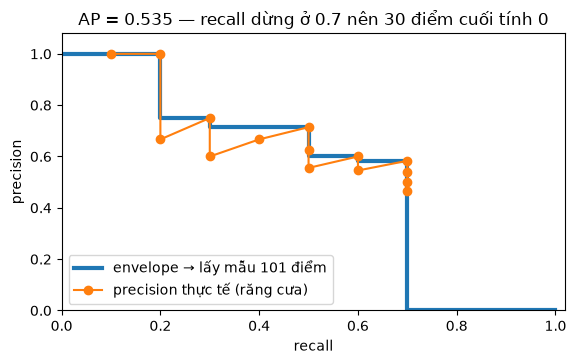

In [19]:
if PROGRESS.get("average_precision") == "ok":
    tp_slide = np.array([1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0]); conf_slide = np.linspace(0.95, 0.25, 15)
    rec = np.cumsum(tp_slide) / 10; prec = np.cumsum(tp_slide) / np.arange(1, 16)
    env = np.maximum.accumulate(prec[::-1])[::-1]
    plt.figure(figsize=(6.5, 3.6))
    plt.step(np.r_[0, rec, rec[-1], 1], np.r_[env[0], env, 0, 0], where="pre", lw=3, label="envelope → lấy mẫu 101 điểm")
    plt.plot(rec, prec, "o-", color="tab:orange", label="precision thực tế (răng cưa)")
    plt.xlabel("recall"); plt.ylabel("precision"); plt.xlim(0, 1.02); plt.ylim(0, 1.08); plt.legend(loc="lower left")
    plt.title(f"AP = {average_precision(tp_slide, conf_slide, 10):.3f} — recall dừng ở 0.7 nên 30 điểm cuối tính 0"); plt.show()
else:
    print("(bỏ qua hình PR — average_precision chưa đạt; đây là phần ⭐ không bắt buộc)")

---
## Phần 2 — Segmentation (30')
🏭 **Mảnh ghép 2: tạo nhãn cho class mới.** COCO không có class "mũ bảo hộ". Muốn fine-tune thì phải có nhãn, mà vẽ tay một mask polygon mất khoảng 80 giây.
Phần này dựng pipeline **detector → SAM → polygon** để máy gán nhãn thay người.

### 2A. Semantic và instance trên cùng một ảnh — 8'
- **Semantic** (YOLO26n-sem, train trên Cityscapes, 19 class): mỗi *pixel* một class.
- **Instance** (Mask R-CNN v2): mỗi *object* một mask riêng.

🔮 **Dự đoán.** Ảnh có 4 người. Nếu lấy bản đồ semantic của class `person` rồi đếm số vùng liên thông, bạn sẽ đếm được mấy "người"?

Semantic : (1080, 810) — tỉ lệ pixel: {'road': '28%', 'sidewalk': '2%', 'building': '19%', 'vegetation': '5%', 'person': '15%', 'train': '31%'}


Instance : (22, 1, 1080, 810) → giữ score > 0.5 → (5, 1080, 810) ['person', 'bus', 'person', 'person', 'person']


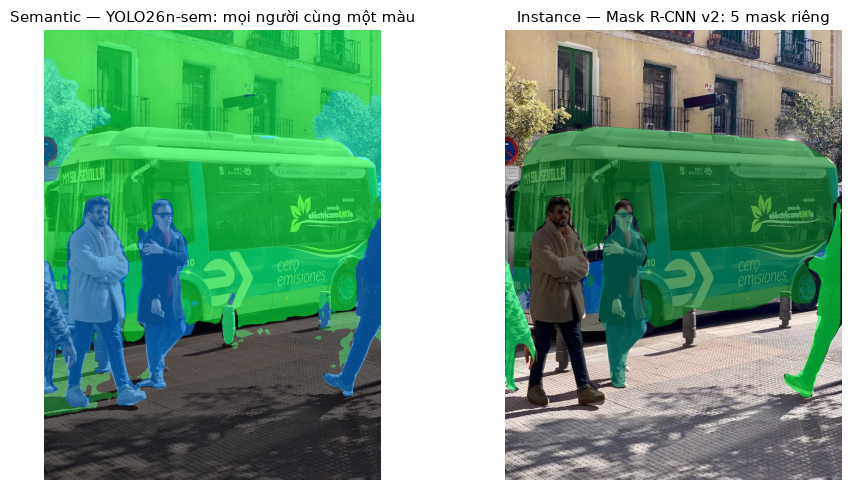

In [20]:
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2

# --- Semantic: mỗi pixel một class ---
yolo_sem = YOLO("yolo26n-sem.pt")
r_sem = yolo_sem.predict(IMG_BUS, verbose=False)[0]
sem = r_sem.semantic_mask.data.cpu().long()                       # (H, W): class id của từng pixel
SEM_NAMES = yolo_sem.names
sem_ids = sem.unique().tolist()
print("Semantic :", tuple(sem.shape), "— tỉ lệ pixel:",
      {SEM_NAMES[k]: f"{(sem == k).float().mean():.0%}" for k in sem_ids if (sem == k).float().mean() > 0.01})

# --- Instance: mỗi object một mask ---
w_ins = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT                  # COCO box AP 47.4 / mask AP 41.8
mrcnn = maskrcnn_resnet50_fpn_v2(weights=w_ins).eval().to(DEVICE)
with torch.inference_mode():
    o = mrcnn([w_ins.transforms()(img_bus).to(DEVICE)])[0]
o = {k: v.cpu() for k, v in o.items()}
keep = o["scores"] > 0.5
masks_mrcnn = o["masks"][keep, 0] > 0.5                           # (N,1,H,W) xác suất → (N,H,W) bool
labels_mrcnn = o["labels"][keep]
print("Instance :", tuple(o["masks"].shape), "→ giữ score > 0.5 →", tuple(masks_mrcnn.shape), [COCO_TV[c] for c in labels_mrcnn])

show(draw_segmentation_masks(img_bus, torch.stack([sem == k for k in sem_ids]), alpha=0.6),
     draw_segmentation_masks(img_bus, masks_mrcnn, alpha=0.6),
     titles=["Semantic — YOLO26n-sem: mọi người cùng một màu", f"Instance — Mask R-CNN v2: {len(masks_mrcnn)} mask riêng"])

Vùng liên thông của class 'person': 8 vùng, diện tích (pixel): [106185, 20309, 1241, 17, 8, 4, 4, 3]
Mask R-CNN: 4 người · Thực tế: 4 người
Bên trong box 'bus' của detector, semantic nói: {'road': '5%', 'vegetation': '3%', 'person': '23%', 'train': '63%'}


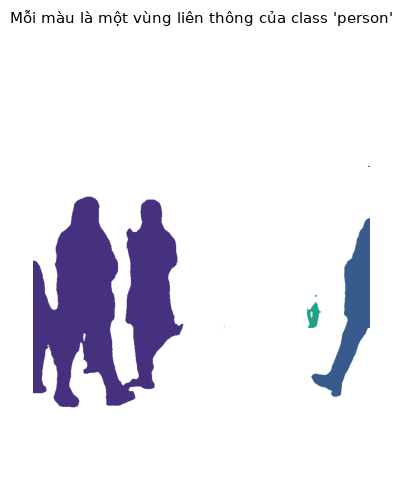

In [21]:
# Đếm người bằng bản đồ semantic có được không?
person_id = next(k for k, v in SEM_NAMES.items() if v == "person")
n_cc, cc, stats, _ = cv2.connectedComponentsWithStats((sem == person_id).numpy().astype(np.uint8))
n_inst = int((labels_mrcnn == COCO_TV.index("person")).sum())
print(f"Vùng liên thông của class 'person': {n_cc - 1} vùng, diện tích (pixel): {sorted(stats[1:, cv2.CC_STAT_AREA].tolist(), reverse=True)}")
print(f"Mask R-CNN: {n_inst} người · Thực tế: 4 người")

# Xe buýt được gán class gì?
bx1, by1, bx2, by2 = r_e2e.boxes.xyxy[r_e2e.boxes.cls == 5][0].int().tolist()
ids, cnt = sem[by1:by2, bx1:bx2].unique(return_counts=True)
print("Bên trong box 'bus' của detector, semantic nói:", {SEM_NAMES[int(i)]: f"{int(n) / int(cnt.sum()):.0%}" for i, n in zip(ids, cnt) if n / cnt.sum() > 0.03})
show(np.ma.masked_equal(cc, 0), titles=["Mỗi màu là một vùng liên thông của class 'person'"], size=5)

❓ **Q4.** (a) Vì sao đếm vùng liên thông trên bản đồ semantic cho ra số người sai — nêu một nguyên nhân gây đếm **thiếu** và một nguyên nhân gây đếm **thừa**. Panoptic segmentation giải quyết việc này thế nào?
(b) Bản đồ semantic gán xe buýt vào class nào? Vì sao model lại nhầm như vậy?

In [22]:
Q4 = """
(a) Bản đồ semantic chỉ phân loại từng pixel riêng rẽ mà không phân biệt được các cá thể (instance) cùng class:
- Nguyên nhân đếm thiếu: Khi hai hoặc nhiều người đứng sát nhau, chạm nhau hoặc che khuất nhau, các pixel mang nhãn 'person' dính liền thành một mảng liên thông duy nhất, hàm connectedComponents sẽ chỉ đếm là 1 người.
- Nguyên nhân đếm thừa: Khi một người bị che khuất ở giữa bởi vật thể khác (ví dụ lan can, cột, cánh cửa) hoặc các bộ phận cơ thể (hai chân, đầu và tay) bị phân tách thành các vùng pixel không tiếp xúc nhau, mỗi mảnh tách rời trở thành một connected component độc lập, dẫn đến đếm thành nhiều người (như trong ảnh bus.jpg có 4 người nhưng đếm thành 7 vùng liên thông).
- Giải pháp từ Panoptic segmentation: Panoptic thống nhất semantic segmentation (cho các vùng nền 'stuff' không đếm được như đường xá, vỉa hè) và instance segmentation (cho các đối tượng đếm được 'things' như người, xe), gán cho mỗi pixel cả nhãn lớp lẫn một instance ID duy nhất. Nhờ đó, các cá thể dù đứng sát nhau hay chạm pixel vẫn được phân tách rõ ràng.

(b) Bản đồ semantic gán phần lớn pixel của xe buýt vào class 'train' (tàu hỏa / tàu điện). Model bị nhầm vì YOLO26n-sem được huấn luyện trên dataset Cityscapes. Trong Cityscapes, các toa tàu điện đô thị (tram/train) và xe buýt có hình khối hộp chữ nhật kéo dài, các dãy cửa sổ kính liên tiếp và bối cảnh giao thông đường phố rất giống nhau; đồng thời góc chụp cận cảnh chiếc xe buýt với các ô kính lớn làm model kích hoạt các đặc trưng tương đồng với toa tàu điện.
"""


### 2B. 🧩 Mask IoU và chuyển đổi polygon ↔ mask — 10'
Ba hàm "data engineering" bạn sẽ dùng mỗi khi đánh giá model segmentation hoặc tạo nhãn.

**Bước 1/3 — `mask_iou`.** Với mask nhị phân, *giao* chính là số pixel cùng bằng 1, tức là **tích vô hướng** của hai vector 0/1.
Vì vậy một phép nhân ma trận cho ra cả bảng giao (N, M).

🔮 **Dự đoán.** Hai hình vuông 50×50, lệch nhau 25 pixel theo cả hai chiều. Giao = ? Hợp = ? IoU = ?

In [23]:
def mask_iou(m1: torch.Tensor, m2: torch.Tensor) -> torch.Tensor:
    """m1: (N,H,W) bool, m2: (M,H,W) bool → ma trận IoU (N,M)."""
    # Bước 1 — duỗi mỗi mask thành một vector 0/1 dài H·W
    a = m1.flatten(1).float()                                     # (N, H·W)
    b = m2.flatten(1).float()                                     # (M, H·W)  🧩
    # Bước 2 — bảng giao (N,M) bằng một phép nhân ma trận
    inter = a @ b.T                                               # (N,M)  🧩
    # Bước 3 — diện tích mỗi mask = tổng theo hàng; hợp = |A| + |B| − giao (nhớ broadcast như ở box_iou)
    area_a, area_b = a.sum(1), b.sum(1)
    union = area_a[:, None] + area_b[None, :] - inter             # (N,M)  🧩
    return inter / union.clamp(min=1e-9)


check_mask_iou()


✅ mask_iou đạt (4 phép thử)


<details><summary>💡 Gợi ý — <code>mask_iou</code></summary>

`b` viết như `a`. `inter = a @ b.T` (ma trận (N, H·W) nhân (H·W, M)). `union = area_a[:, None] + area_b[None, :] - inter`.
</details>

**Bước 2/3 — `polygon_to_mask`** và **Bước 3/3 — `mask_to_yolo_seg`.** Nhãn YOLO-seg mỗi dòng là `class x1 y1 x2 y2 … xn yn`,
toạ độ đỉnh polygon **chuẩn hoá về [0, 1]** (x chia cho W, y chia cho H). Mỗi hàm chỉ cần điền 1–2 dòng.

In [24]:
def polygon_to_mask(poly: np.ndarray, h: int, w: int) -> np.ndarray:
    """poly: (K,2) toạ độ pixel (x, y) → mask bool (H,W)."""
    mask = np.zeros((h, w), dtype=np.uint8)
    pts = np.round(poly).astype(np.int32)                         # cv2 cần toạ độ nguyên
    # Tô kín đa giác bằng giá trị 1: cv2.fillPoly(ảnh, [danh sách đỉnh], màu)
    cv2.fillPoly(mask, [pts], 1)                                  # 🧩
    return mask.astype(bool)


def mask_to_yolo_seg(mask: np.ndarray, cls_id: int, simplify: float = 0.002) -> str:
    """mask bool (H,W) → 1 dòng nhãn YOLO-seg 'class x1 y1 x2 y2 ...' (toạ độ chuẩn hoá)."""
    h, w = mask.shape
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return ""
    # Bước 1 — mask có thể vỡ thành nhiều mảnh: lấy contour có DIỆN TÍCH lớn nhất (cv2.contourArea)
    cnt = max(contours, key=cv2.contourArea)                      # 🧩
    # Bước 2 (viết sẵn) — bỏ bớt đỉnh thừa
    cnt = cv2.approxPolyDP(cnt, simplify * cv2.arcLength(cnt, True), True).reshape(-1, 2)     # (K,2) pixel (x, y)
    if len(cnt) < 3:
        return ""
    # Bước 3 — chuẩn hoá về [0, 1]: x chia cho W, y chia cho H
    norm = cnt / np.array([w, h])                                 # (K,2)  🧩
    return f"{cls_id} " + " ".join(f"{v:.6f}" for v in norm.flatten())


check_polygon_to_mask()
check_mask_to_yolo_seg()


✅ polygon_to_mask đạt (2 phép thử)
✅ mask_to_yolo_seg đạt (4 phép thử)


<details><summary>💡 Gợi ý — polygon ↔ mask</summary>

`polygon_to_mask`: `cv2.fillPoly(mask, [pts], 1)`.
`mask_to_yolo_seg`: `cnt = max(contours, key=cv2.contourArea)` và `norm = cnt / np.array([w, h])` (cột 0 là x, cột 1 là y).
</details>

In [25]:
gate("2B")        # 🚦 hết 10 phút mà chưa xong? → gate("2B", lifeline=True)

✅ Mục 2B xong: mask_iou, polygon_to_mask, mask_to_yolo_seg. Đi tiếp!


**Ghép cặp bằng Hungarian matching**

| YOLO26n-seg | Mask R-CNN v2 | mask IoU |
|---|---|---|
| #0 person | #0 person | 0.939 |
| #1 person | #2 person | 0.842 |
| #2 bus | #1 bus | 0.933 |
| #3 person | #3 person | 0.922 |
| #4 person | #4 person | 0.890 |

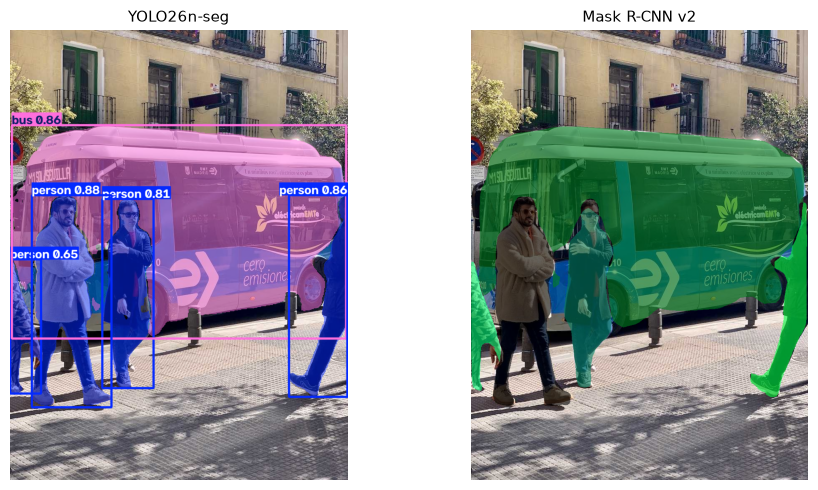

In [26]:
# Áp dụng: mask của YOLO26n-seg giống mask của Mask R-CNN đến đâu? Ghép cặp bằng Hungarian matching (như DETR).
yolo_seg = YOLO("yolo26n-seg.pt")
rs = yolo_seg.predict(IMG_BUS, conf=0.25, verbose=False)[0]
H, W = img_bus.shape[-2:]
masks_yolo = torch.from_numpy(np.stack([polygon_to_mask(p, H, W) for p in rs.masks.xy]))     # polygon của YOLO → mask
iou_mat = mask_iou(masks_yolo, masks_mrcnn)                                                # (số mask YOLO, số mask Mask R-CNN)
ri, ci = linear_sum_assignment(-iou_mat.numpy())                                           # ghép 1–1 sao cho tổng IoU lớn nhất
show_table([{"YOLO26n-seg": f"#{i} {NAMES[int(rs.boxes.cls[i])]}", "Mask R-CNN v2": f"#{j} {COCO_TV[labels_mrcnn[j]]}",
             "mask IoU": float(iou_mat[i, j])} for i, j in zip(ri, ci)], title="Ghép cặp bằng Hungarian matching")
show(bgr_to_u8(rs.plot()), draw_segmentation_masks(img_bus, masks_mrcnn, alpha=0.6), titles=["YOLO26n-seg", "Mask R-CNN v2"])

❓ **Q5.** (a) YOLO26-seg tạo mask bằng *32 prototype dùng chung × hệ số riêng của từng object*, còn Mask R-CNN dự đoán một mask 28×28 cho từng RoI. Mỗi cách cho biên mask thô ở object **lớn** hay **nhỏ**, vì sao?
(b) Ô trên ghép cặp bằng Hungarian matching. Nếu thay bằng "mỗi mask YOLO lấy mask Mask R-CNN có IoU cao nhất" thì có thể sai ở đâu?

In [27]:
Q5 = """
(a) 
- Mask R-CNN dự đoán mask cố định 28×28 cho mỗi RoI rồi nội suy (bilinear upsampling) về kích thước bounding box:
  + Với object nhỏ: Ma trận 28×28 có mật độ phân giải tương đối dày so với kích thước thực của object, nên biên mask chi tiết, mịn màng.
  + Với object lớn: Kéo giãn ma trận 28×28 ra kích thước hàng trăm pixel của box lớn làm biên mask bị mờ nhòe, răng cưa và mất chi tiết viền (pixelated/interpolated blur).
- YOLO26-seg (kiểu ProtoNet / YOLACT) tạo mask bằng cách kết hợp tuyến tính 32 prototype mask (có kích thước cố định theo ảnh, ví dụ 160×160) với hệ số mask coefficients riêng, rồi crop theo box:
  + Với object lớn: Vùng crop chiếm diện tích lớn trên bản đồ prototype 160×160, bảo toàn được nhiều pixel chi tiết nên biên mask rất mịn và sắc nét.
  + Với object nhỏ: Vùng crop chỉ chiếm vài pixel trên bản đồ prototype, dẫn đến việc mask bị thô ráp, vỡ khối khi nội suy lên kích thước ảnh gốc.

(b) Nếu thay Hungarian matching bằng giải thuật tham lam (greedy) "mỗi mask YOLO lấy mask Mask R-CNN có IoU cao nhất":
- Phương pháp này là ánh xạ nhiều-về-một (many-to-one), không bảo đảm tính ghép đôi 1-1 (bipartite matching).
- Khi có hai dự đoán YOLO cùng chồng lấn lên một đối tượng Mask R-CNN (ví dụ một mask bao quát và một mask bộ phận), cả hai sẽ cùng tranh giành và ghép cặp với cùng một mask Mask R-CNN đó, trong khi một mask Mask R-CNN hợp lệ khác có thể bị bỏ sót.
- Hungarian matching giải quyết bài toán tối ưu phân công toàn cục (Global Bipartite Matching) với ràng buộc 1-1, tối đa hóa tổng IoU trên toàn bộ tập ghép cặp mà không bị trùng lặp.
"""


### 2C. SAM 2.1 theo prompt → auto-label — 12'
SAM = **image encoder** nặng (chạy 1 lần mỗi ảnh) + **prompt encoder** + **mask decoder** nhẹ (chạy cho từng prompt).
Prompt có thể là một điểm hoặc một box. Pipeline gán nhãn tự động: **box từ YOLO26 → SAM → mask → polygon YOLO-seg**.

🔮 **Dự đoán.** Ta thử hai prompt **một điểm**, cả hai đều nằm trong box của cùng một người: điểm A ở chính giữa box, điểm B thấp hơn (ở 80% chiều cao box). SAM sẽ tô gì ở mỗi trường hợp?

SAM 2.1-tiny: 5 mask từ 5 box prompt trong 0.23 giây


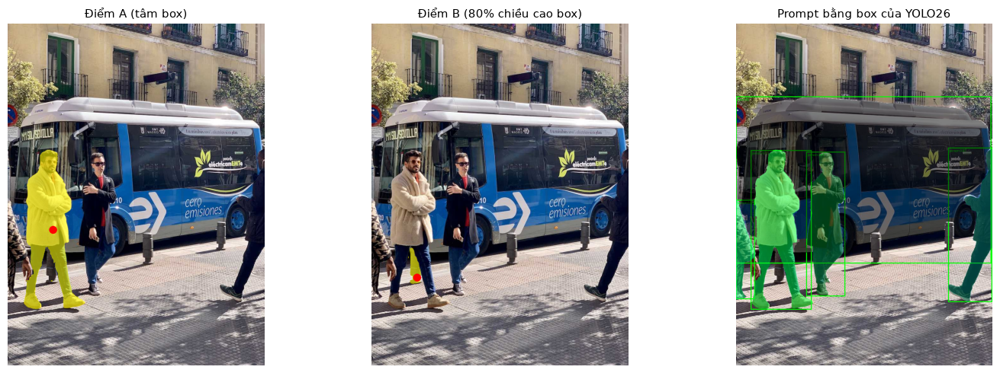

Điểm A: mask rộng  47441 pixel, IoU với mask-từ-box của người đó = 0.99
Điểm B: mask rộng   2714 pixel, IoU với mask-từ-box của người đó = 0.00


In [28]:
sam = SAM("sam2.1_t.pt")                                          # SAM 2.1 tiny
det_boxes, det_cls, det_conf = r_e2e.boxes.xyxy.cpu(), r_e2e.boxes.cls.cpu().int(), r_e2e.boxes.conf.cpu()

# (1) Prompt bằng MỘT ĐIỂM, lấy trong box 'person' lớn nhất: A = tâm box, B = cùng cột nhưng ở 80% chiều cao box
persons = det_boxes[det_cls == 0]
big = persons[((persons[:, 2] - persons[:, 0]) * (persons[:, 3] - persons[:, 1])).argmax()]
px = float((big[0] + big[2]) / 2)
pts = {"A": (px, float((big[1] + big[3]) / 2)), "B": (px, float(big[1] + 0.8 * (big[3] - big[1])))}
m_pts = {k: sam(IMG_BUS, points=[list(xy)], labels=[1], verbose=False)[0].masks.data.cpu().bool() for k, xy in pts.items()}

# (2) Prompt bằng BOX: toàn bộ box của detector
t0 = time.time()
masks_sam = sam(IMG_BUS, bboxes=det_boxes.tolist(), verbose=False)[0].masks.data.cpu().bool()       # (N,H,W) ở độ phân giải ảnh gốc
print(f"SAM 2.1-tiny: {len(masks_sam)} mask từ {len(det_boxes)} box prompt trong {time.time() - t0:.2f} giây")

pt_vis = {k: draw_keypoints(draw_segmentation_masks(img_bus, m_pts[k], alpha=0.6, colors="yellow"), torch.tensor([[list(xy)]]), colors="red", radius=12)
          for k, xy in pts.items()}
box_vis = draw_segmentation_masks(draw_det(img_bus, det_boxes, det_cls, det_conf, "lime", NAMES), masks_sam, alpha=0.5)
show(pt_vis["A"], pt_vis["B"], box_vis, titles=["Điểm A (tâm box)", "Điểm B (80% chiều cao box)", "Prompt bằng box của YOLO26"])
for k in pts:
    print(f"Điểm {k}: mask rộng {int(m_pts[k].sum()):6d} pixel, IoU với mask-từ-box của người đó = {float(mask_iou(m_pts[k], masks_sam).max()):.2f}")

5 0.012346 0.348148 0.016049 0.431481 0.023457 0.417593 0.030864 0.437037 0.013580 0.438889 0.030864 0.452778 0.020988 0.544444 0.060494 0.621296 0.080247 0.624 ...


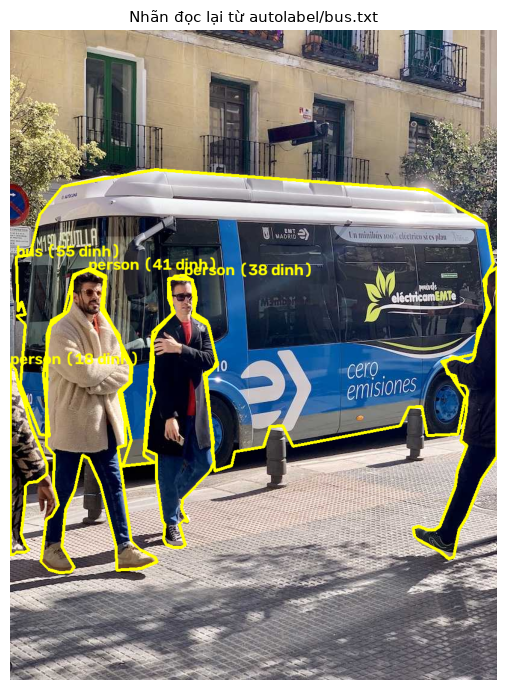

IoU giữa polygon đã lưu và mask SAM gốc: [0.97, 0.982, 0.967, 0.978, 0.983]
✅ autolabel/bus.txt hợp lệ: 5 object, toạ độ chuẩn hoá, polygon khớp mask.


In [29]:
# (3) Auto-label: mask của SAM → file nhãn YOLO-seg, dùng mask_to_yolo_seg của BẠN
lines = [mask_to_yolo_seg(m.numpy(), int(k)) for m, k in zip(masks_sam, det_cls)]
Path("autolabel").mkdir(exist_ok=True)
Path("autolabel/bus.txt").write_text("\n".join(l for l in lines if l) + "\n")
print(Path("autolabel/bus.txt").read_text()[:160], "...")

# (4) Luôn vẽ lại nhãn lên ảnh trước khi train: đọc file → polygon → mask, dùng polygon_to_mask của BẠN
canvas = cv2.cvtColor(cv2.imread(IMG_BUS), cv2.COLOR_BGR2RGB)
rebuilt = []
for line in Path("autolabel/bus.txt").read_text().splitlines():
    cls_id, coords = int(line.split()[0]), np.array(line.split()[1:], dtype=float).reshape(-1, 2)
    poly = coords * [W, H]                                        # bỏ chuẩn hoá: nhân lại với (W, H)
    rebuilt.append(polygon_to_mask(poly, H, W))
    cv2.polylines(canvas, [np.round(poly).astype(np.int32)], True, (255, 255, 0), 4)
    cv2.putText(canvas, f"{NAMES[cls_id]} ({len(poly)} dinh)", tuple(np.round(poly[0]).astype(int)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)
roundtrip = mask_iou(torch.from_numpy(np.stack(rebuilt)), masks_sam).diagonal()
show(canvas, titles=["Nhãn đọc lại từ autolabel/bus.txt"], size=7)
print("IoU giữa polygon đã lưu và mask SAM gốc:", [round(float(v), 3) for v in roundtrip])
check_autolabel(ref_masks=masks_sam)

❓ **Q6.** (a) Điểm A và điểm B cho ra mask của cái gì? Vì sao khi gán nhãn tự động, prompt bằng box an toàn hơn prompt bằng một điểm?
(b) Khi nào nên dùng SAM trực tiếp lúc triển khai, khi nào chỉ dùng SAM để **tạo nhãn** rồi train một YOLO26-seg nhỏ?

In [30]:
Q6 = """
(a) 
- Điểm A (ở tâm box) rơi vào phần thân/áo, SAM phân đoạn thành công toàn bộ cơ thể người (IoU ≈ 0.99 với mask từ box).
- Điểm B (ở 80% chiều cao box) rơi vào phần chân/quần hoặc gót giày, SAM chỉ phân đoạn một mảnh cục bộ (chiếc quần hoặc ống chân) với diện tích rất nhỏ (IoU ≈ 0.00 so với toàn thể người).
- Prompt bằng box an toàn hơn prompt bằng điểm vì bounding box cung cấp đồng thời phạm vi không gian và tỷ lệ bao bọc (extent) của toàn bộ thực thể, giúp SAM xác định rõ ranh giới tổng thể. Trong khi đó, prompt bằng 1 điểm gặp phải tính nhập nhằng cấu trúc phân cấp ('part vs. whole ambiguity') - SAM không biết người dùng muốn lấy toàn bộ người hay chỉ một bộ phận quần áo.

(b) 
- Nên dùng SAM trực tiếp lúc triển khai: Khi hệ thống tương tác người dùng (interactive annotation, UI click-to-segment), hoặc môi trường zero-shot / open-vocabulary cần phân đoạn mọi đối tượng bất kỳ chưa từng thấy, không đòi hỏi tốc độ thời gian thực (offline batch) và có hạ tầng máy chủ GPU mạnh mẽ.
- Nên dùng SAM để tạo nhãn rồi train YOLO26-seg nhỏ: Khi bài toán triển khai yêu cầu thời gian thực (real-time edge deployment, camera giám sát 30-60 FPS) trên thiết bị biên có tài nguyên giới hạn (CPU, edge GPU, NPU). SAM quá nặng (~hàng trăm ms) không thể chạy real-time ở production, trong khi YOLO26-seg rất nhẹ (~vài ms) và nhỏ gọn, tối ưu hoàn hảo cho edge inference.
"""


---
## Phần 3 — Keypoints và Pose (25')
🏭 **Mảnh ghép 3: phát hiện người ngã.** Box chỉ cho biết người ở đâu. Muốn biết *tư thế* thì cần cấu trúc bên trong object: K điểm có tên và có thứ tự.

### 3A. Hai cách ra keypoint: heatmap và hồi quy trực tiếp — 8'
- **Keypoint R-CNN** (top-down trong một model): detect người → RoIAlign → 17 heatmap cho mỗi người → lấy argmax.
- **YOLO26n-pose** (one-stage): một lần forward ra box + 17 keypoint cho mọi người, hồi quy toạ độ trực tiếp.

In [31]:
from torchvision.models.detection import keypointrcnn_resnet50_fpn

w_kp = KeypointRCNN_ResNet50_FPN_Weights.DEFAULT                  # COCO keypoint AP 65.0
kprcnn = keypointrcnn_resnet50_fpn(weights=w_kp).eval().to(DEVICE)
KPT_NAMES = w_kp.meta["keypoint_names"]                           # 17 keypoint theo thứ tự COCO
SKELETON = [(15, 13), (13, 11), (16, 14), (14, 12), (11, 12), (5, 11), (6, 12), (5, 6), (5, 7), (6, 8),
            (7, 9), (8, 10), (1, 2), (0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 6)]

with torch.inference_mode():
    ok = kprcnn([w_kp.transforms()(img_zidane).to(DEVICE)])[0]
ok = {k: v.cpu() for k, v in ok.items()}
keep = ok["scores"] > 0.7
kp_rcnn, kp_rcnn_score = ok["keypoints"][keep], ok["keypoints_scores"][keep]
print("Keypoint R-CNN:", tuple(kp_rcnn.shape), "= N × K × (x, y, v) · điểm từng keypoint:", tuple(kp_rcnn_score.shape), "(là LOGIT của heatmap, không phải xác suất)")

yolo_pose = YOLO("yolo26n-pose.pt")
rp = yolo_pose.predict(IMG_ZIDANE, conf=0.5, verbose=False)[0]
kp_yolo, kp_yolo_conf = rp.keypoints.xy.cpu(), rp.keypoints.conf.cpu()
print("YOLO26n-pose  :", tuple(kp_yolo.shape), "· conf từng keypoint:", tuple(kp_yolo_conf.shape), "(xác suất 0–1)")
show_table([{"#": i, "keypoint": n, "x": round(float(kp_yolo[0, i, 0])), "y": round(float(kp_yolo[0, i, 1])),
             "conf YOLO": float(kp_yolo_conf[0, i]), "logit R-CNN": float(kp_rcnn_score[0, i])} for i, n in enumerate(KPT_NAMES)],
           title=f"Người 0 trên zidane.jpg (ảnh cao {img_zidane.shape[1]} px — để ý y của các keypoint chân)")

Keypoint R-CNN: (2, 17, 3) = N × K × (x, y, v) · điểm từng keypoint: (2, 17) (là LOGIT của heatmap, không phải xác suất)


YOLO26n-pose  : (2, 17, 2) · conf từng keypoint: (2, 17) (xác suất 0–1)


**Người 0 trên zidane.jpg (ảnh cao 720 px — để ý y của các keypoint chân)**

| # | keypoint | x | y | conf YOLO | logit R-CNN |
|---|---|---|---|---|---|
| 0 | nose | 999 | 194 | 0.998 | 15.023 |
| 1 | left_eye | 1023 | 169 | 0.991 | 14.835 |
| 2 | right_eye | 965 | 164 | 0.999 | 15.893 |
| 3 | left_ear | 1044 | 187 | 0.182 | 11.753 |
| 4 | right_ear | 902 | 177 | 0.981 | 13.928 |
| 5 | left_shoulder | 1033 | 337 | 0.966 | 10.004 |
| 6 | right_shoulder | 835 | 328 | 0.996 | 6.702 |
| 7 | left_elbow | 1051 | 507 | 0.350 | 1.161 |
| 8 | right_elbow | 796 | 527 | 0.940 | 5.465 |
| 9 | left_wrist | 1071 | 483 | 0.309 | 4.289 |
| 10 | right_wrist | 976 | 467 | 0.931 | 10.375 |
| 11 | left_hip | 1047 | 706 | 0.270 | 2.500 |
| 12 | right_hip | 909 | 714 | 0.420 | 4.766 |
| 13 | left_knee | 1076 | 715 | 0.001 | -3.469 |
| 14 | right_knee | 931 | 718 | 0.002 | -1.533 |
| 15 | left_ankle | 1042 | 712 | 0.001 | -3.648 |
| 16 | right_ankle | 929 | 700 | 0.001 | -0.970 |

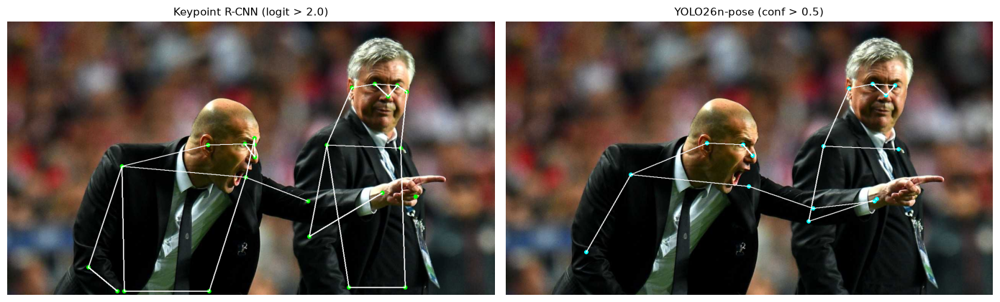

In [32]:
KP_THR = 2.0          # ngưỡng trên LOGIT của Keypoint R-CNN. Thử đổi thành -100 (không lọc) rồi chạy lại ô này.

vis_rcnn = draw_keypoints(img_zidane, kp_rcnn[..., :2], connectivity=SKELETON, colors="lime", radius=5, width=3, visibility=kp_rcnn_score > KP_THR)
vis_yolo = draw_keypoints(img_zidane, kp_yolo, connectivity=SKELETON, colors="cyan", radius=5, width=3, visibility=kp_yolo_conf > 0.5)
show(vis_rcnn, vis_yolo, titles=[f"Keypoint R-CNN (logit > {KP_THR})", "YOLO26n-pose (conf > 0.5)"], size=7)

❓ **Q7.** Đổi `KP_THR = -100` rồi chạy lại ô trên. Đầu gối và mắt cá của hai người nằm **ngoài khung hình**, vậy Keypoint R-CNN vẽ chúng ở đâu? Điều đó nói gì về cách giải mã heatmap bằng argmax, và vì sao mỗi keypoint cần đi kèm một điểm tin cậy?

In [33]:
Q7 = """
- Khi đổi KP_THR = -100 (bỏ ngưỡng lọc logit), Keypoint R-CNN vẫn vẽ đầy đủ cả đầu gối và mắt cá chân, ép chúng dồn xuống mép đáy của bounding box / mép dưới của ảnh hoặc phân tán ngẫu nhiên tại các vị trí nhiễu trong RoI dù chúng thực tế nằm ngoài khung hình.
- Nhận xét về cách giải mã heatmap bằng argmax:
  + Toán tử argmax luôn tìm và trả về toạ độ có giá trị lớn nhất trên ma trận 2D heatmap, bất kể đỉnh đó có mang giá trị âm lớn hay chỉ là nhiễu nền khi keypoint thực tế bị che khuất hoặc nằm ngoài khung hình. Argmax bản chất không có khả năng tự phát hiện sự vắng mặt của điểm mốc.
- Vì sao mỗi keypoint cần đi kèm một điểm tin cậy (score/confidence):
  + Điểm tin cậy (logit/xác suất) cho biết mức độ chắc chắn của model về sự tồn tại của keypoint đó. Nếu không có điểm tin cậy để đặt ngưỡng lọc, hệ thống sẽ sử dụng toạ độ rác từ argmax, dẫn đến việc tính toán góc khớp sai lệch hoàn toàn và gây ra các báo động giả nghiêm trọng trong các luật nghiệp vụ (như phát hiện tư thế ngã).
"""


### 3B. 🧩 OKS — "IoU của keypoint" — 10'
$$\mathrm{OKS}=\frac{\sum_i \exp\!\left(-\dfrac{d_i^2}{2\,s^2\,k_i^2}\right)\,\delta(v_i>0)}{\sum_i \delta(v_i>0)},\qquad k_i = 2\sigma_i$$
- $d_i$: khoảng cách giữa keypoint dự đoán và GT · $s^2$: **diện tích** object;
- $\sigma_i$: độ lệch giữa những người gán nhãn cho keypoint $i$ (mắt 0.025, hông 0.107);
- chỉ tính các keypoint có nhãn ($v_i > 0$).

🔮 **Dự đoán** (câu checkpoint trên slide). Cùng một người, dự đoán lệch 8 pixel ở **mắt** và ở **hông**. Keypoint nào bị phạt nặng hơn?

In [34]:
COCO_SIGMAS = np.array([.26, .25, .25, .35, .35, .79, .79, .72, .72, .62, .62, 1.07, 1.07, .87, .87, .89, .89]) / 10


def oks(kpt_gt: np.ndarray, kpt_pred: np.ndarray, area: float, sigmas: np.ndarray = COCO_SIGMAS, vis: np.ndarray = None) -> float:
    """kpt_gt, kpt_pred: (K,2) pixel · area: diện tích object (chính là s²) · sigmas: (K,) · vis: (K,) bool, keypoint GT có nhãn."""
    kpt_gt, kpt_pred = np.asarray(kpt_gt, dtype=float), np.asarray(kpt_pred, dtype=float)
    if vis is None:
        vis = np.ones(len(kpt_gt), dtype=bool)
    # Bước 1 — bình phương khoảng cách của từng keypoint: d² = Δx² + Δy²
    d2 = ((kpt_gt - kpt_pred) ** 2).sum(axis=1)                  # (K,)  🧩
    # Bước 2 (viết sẵn) — hằng số của từng keypoint
    k = 2 * np.asarray(sigmas)
    # Bước 3 — độ giống của từng keypoint: exp(−d² / (2 · s² · k²)), với s² = area
    sim = np.exp(-d2 / (2 * area * k ** 2))                       # (K,)  🧩
    # Bước 4 — trung bình trên các keypoint CÓ NHÃN
    return float(sim[vis].mean())                                 # 🧩


check_oks()


✅ oks đạt (3 phép thử)


<details><summary>💡 Gợi ý — <code>oks</code></summary>

Bước 1: `((kpt_gt - kpt_pred) ** 2).sum(axis=1)`. Bước 3: `np.exp(-d2 / (2 * area * k ** 2))` — chú ý `area` đã là $s^2$, đừng bình phương thêm.
Bước 4: `float(sim[vis].mean())`.
</details>

In [35]:
gate("3B")        # 🚦 hết 10 phút mà chưa xong? → gate("3B", lifeline=True)

✅ Mục 3B xong: oks. Đi tiếp!


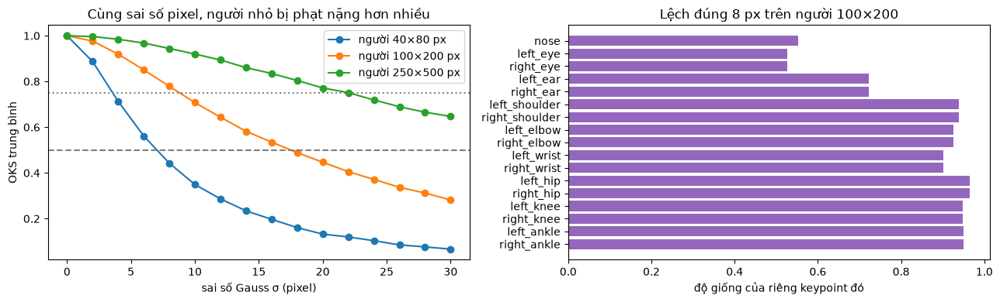

Lệch 8 px: mắt còn 0.53, hông còn 0.97 → mắt bị phạt nặng hơn.


In [36]:
# Thí nghiệm: cùng sai số pixel, OKS thay đổi thế nào theo KÍCH THƯỚC người và theo TỪNG keypoint?
rng = np.random.default_rng(0)
gt17 = rng.uniform(0, 100, (17, 2))
noise_px = np.arange(0, 31, 2)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for label, area_ in [("40×80 px", 40 * 80), ("100×200 px", 100 * 200), ("250×500 px", 250 * 500)]:
    curve = [np.mean([oks(gt17, gt17 + rng.normal(0, n, gt17.shape), area_) for _ in range(200)]) for n in noise_px]
    ax[0].plot(noise_px, curve, marker="o", label=f"người {label}")
ax[0].axhline(0.5, ls="--", c="gray"); ax[0].axhline(0.75, ls=":", c="gray")
ax[0].set(xlabel="sai số Gauss σ (pixel)", ylabel="OKS trung bình", title="Cùng sai số pixel, người nhỏ bị phạt nặng hơn nhiều"); ax[0].legend()

d_px, area_ = 8.0, 100 * 200
per_kpt = np.exp(-d_px ** 2 / (2 * area_ * (2 * COCO_SIGMAS) ** 2))
ax[1].barh(KPT_NAMES, per_kpt, color="tab:purple"); ax[1].invert_yaxis()
ax[1].set(xlabel="độ giống của riêng keypoint đó", title=f"Lệch đúng {d_px:.0f} px trên người 100×200")
plt.tight_layout(); plt.show()
print(f"Lệch 8 px: mắt còn {per_kpt[1]:.2f}, hông còn {per_kpt[11]:.2f} → mắt bị phạt nặng hơn.")

❓ **Q8.** Từ đồ thị bên trái: sai số khoảng bao nhiêu pixel thì OKS của người 40×80 rơi xuống dưới 0.5? Người 250×500 thì sao?
Vì sao $\sigma$ của mắt nhỏ hơn hông nhiều lần? Điều này có ý nghĩa gì với camera cổng gắn trên cao, nơi mỗi người chỉ cao khoảng 80 pixel?

In [37]:
Q8 = """
- Từ đồ thị thực nghiệm bên trái:
  + Với người nhỏ 40×80 px (diện tích 3 200 px²): Chỉ cần sai số khoảng 3–4 pixel là OKS trung bình đã rơi xuống dưới 0.5.
  + Với người lớn 250×500 px (diện tích 125 000 px²): Sai số phải lên tới khoảng 20–25 pixel thì OKS mới rơi xuống dưới 0.5.
- Vì sao σ của mắt nhỏ hơn hông nhiều lần:
  + Trong OKS, σ_i thể hiện độ lệch chuẩn gán nhãn giữa các chuyên gia annotator trên COCO (annotator variance). Mắt là một điểm mốc rất rõ ràng, định vị chuẩn xác theo giải phẫu (đồng tử/khóe mắt) nên độ lệch giữa người gán nhãn rất bé (σ = 0.025). Ngược lại, hông là vùng khớp ẩn bên trong cơ thể được che phủ bởi quần áo, không có điểm mốc bề mặt cố định nên độ phân tán gán nhãn rất lớn (σ = 0.107).
- Ý nghĩa với camera cổng trên cao (người chỉ cao ~80 pixel):
  + Ở khoảng cách xa này, toàn bộ vùng mặt chỉ chiếm khoảng 3–5 pixel; độ lệch chỉ 1–2 pixel đã khiến OKS của mắt tụt giảm thê thảm. Do đó hệ thống không nên dựa vào các keypoint nhỏ như mắt/mũi để ra quyết định, mà cần dựa vào các khớp khung xương lớn (vai, hông, đầu gối) có kích thước tương đối và độ tin cậy ổn định hơn.
"""


### 3C. 🧩 Từ keypoint đến luật nghiệp vụ: góc khớp và "ngã" — 7'
Góc tại đỉnh $b$ tạo bởi ba điểm $a$–$b$–$c$:
$$\theta=\arccos\frac{(a-b)\cdot(c-b)}{\lVert a-b\rVert\,\lVert c-b\rVert}$$

In [38]:
def joint_angle(a, b, c) -> float:
    """Góc (độ) tại đỉnh b tạo bởi ba điểm a–b–c. Mỗi điểm là (x, y)."""
    a, b, c = (np.asarray(p, dtype=float) for p in (a, b, c))
    # Bước 1 — hai vector cùng xuất phát từ b
    v1 = a - b
    v2 = c - b                                                    # 🧩
    # Bước 2 — cos θ = (v1 · v2) / (|v1| · |v2|). Gợi ý: np.dot, np.linalg.norm
    cos = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))  # 🧩
    # Bước 3 (viết sẵn) — chặn cos trong [−1, 1] để tránh sai số số học, rồi đổi sang độ
    return float(np.degrees(np.arccos(np.clip(cos, -1.0, 1.0))))


check_joint_angle()


✅ joint_angle đạt (2 phép thử)


<details><summary>💡 Gợi ý — <code>joint_angle</code></summary>

`v2 = c - b` và `cos = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))`.
</details>

In [39]:
gate("3C")        # 🚦 hết giờ mà chưa xong? → gate("3C", lifeline=True)

✅ Mục 3C xong: joint_angle. Đi tiếp!


zidane.jpg — người 0: tay trái: (không đủ tin cậy) | tay phải: 61°
zidane.jpg — người 1: tay trái: 154° | tay phải: (không đủ tin cậy)

Ảnh gốc: tìm thấy 5 người
   người 0: thân nghiêng   1° → đứng
   người 1: không đủ tin cậy (vai hoặc hông bị che / ngoài khung) → không kết luận
   người 2: thân nghiêng   1° → đứng
   người 3: không đủ tin cậy (vai hoặc hông bị che / ngoài khung) → không kết luận
   người 4: không đủ tin cậy (vai hoặc hông bị che / ngoài khung) → không kết luận

Xoay 90° — giả lập người nằm: tìm thấy 3 người
   người 0: thân nghiêng  90° → 🚨 NGÃ?
   người 1: thân nghiêng  94° → 🚨 NGÃ?
   người 2: thân nghiêng  83° → 🚨 NGÃ?


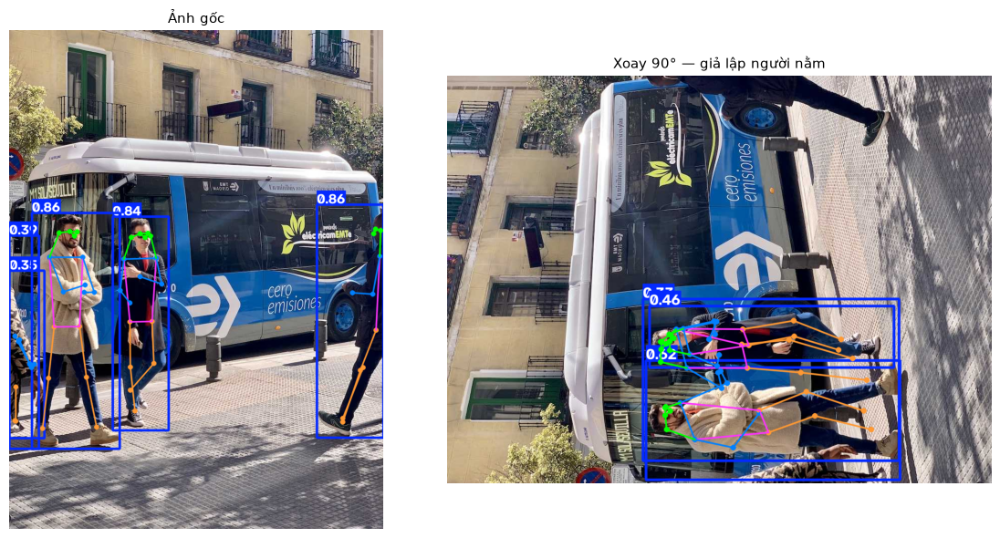

In [40]:
# (1) Góc khuỷu tay trên zidane.jpg — chỉ tin khi cả 3 keypoint đều đủ tin cậy
ARMS = {"tay trái": (5, 7, 9), "tay phải": (6, 8, 10)}            # vai – khuỷu – cổ tay (chỉ số COCO)
for i, (kp, cf) in enumerate(zip(kp_yolo.numpy(), kp_yolo_conf.numpy())):
    parts = [f"{arm}: {joint_angle(kp[s_], kp[e_], kp[w_]):.0f}°" if min(cf[s_], cf[e_], cf[w_]) > 0.5 else f"{arm}: (không đủ tin cậy)"
             for arm, (s_, e_, w_) in ARMS.items()]
    print(f"zidane.jpg — người {i}: " + " | ".join(parts))


# (2) Luật "ngã": góc nghiêng của thân so với phương thẳng đứng
def torso_tilt(kp):
    """0° = đứng thẳng, 90° = nằm ngang. Thân = đoạn nối trung điểm hai vai với trung điểm hai hông."""
    shoulder, hip = (kp[5] + kp[6]) / 2, (kp[11] + kp[12]) / 2
    return joint_angle(shoulder, hip, hip + np.array([0.0, -1.0]))    # điểm thứ ba nằm ngay phía TRÊN hông (trục y của ảnh hướng xuống)


FALL_DEG, KPT_CONF = 60, 0.5
img_bgr = cv2.imread(IMG_BUS)
scenes = {"Ảnh gốc": img_bgr, "Xoay 90° — giả lập người nằm": cv2.rotate(img_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)}
plots = []
for title, im in scenes.items():
    r = yolo_pose.predict(im, conf=0.25, verbose=False)[0]
    plots.append(bgr_to_u8(r.plot(labels=False)))
    print(f"\n{title}: tìm thấy {len(r.boxes)} người")
    for i, (kp, cf) in enumerate(zip(r.keypoints.xy.cpu().numpy(), r.keypoints.conf.cpu().numpy())):
        if cf[[5, 6, 11, 12]].min() < KPT_CONF:
            print(f"   người {i}: không đủ tin cậy (vai hoặc hông bị che / ngoài khung) → không kết luận")
        else:
            tilt = torso_tilt(kp)
            print(f"   người {i}: thân nghiêng {tilt:3.0f}° → {'🚨 NGÃ?' if tilt > FALL_DEG else 'đứng'}")
show(*plots, titles=list(scenes), size=6)

❓ **Q9.** (a) Luật "thân nghiêng > 60°" sẽ **báo nhầm** trong tình huống nào và **bỏ sót** trong tình huống nào? Nêu mỗi loại ít nhất một ca.
(b) Ảnh xoay vẫn có đủ số người như ảnh gốc, nhưng model tìm được ít người hơn. Vì sao?
(c) Một hệ thống cảnh báo ngã thật sự cần thêm những thành phần gì ngoài một luật trên một khung hình?

In [41]:
Q9 = """
(a) 
- Báo nhầm (False Positive): Công nhân cúi người nhặt ốc vít/dụng cụ rơi dưới sàn, công nhân cúi buộc dây giày, hoặc thợ bảo trì bò/ngồi sửa máy dưới gầm bàn. Lúc này thân nghiêng > 60° so với phương thẳng đứng nhưng họ hoàn toàn bình thường không ngã.
- Bỏ sót (False Negative): Người ngã ngửa hoặc ngã sấp theo hướng trục camera (chiếu dọc theo tầm nhìn camera, foreshortening). Khi chiếu lên ảnh 2D, vector vai-hông vẫn gần như thẳng đứng nên góc nghiêng < 60°. Ngoài ra, người ngã nhưng ngồi bệt dựa lưng vào tường/thùng hàng cũng bị bỏ sót.

(b) Ảnh xoay 90° tìm được ít người hơn vì các model detector và pose được huấn luyện với giả định tiên nghiệm về hướng trọng lực (gravity-aligned prior - người đứng/ngồi thẳng). Khi ảnh xoay ngang 90°, hình thái trực quan, tỷ lệ khung hình bounding box và đặc trưng của cơ thể người bị lệch hoàn toàn khỏi phân phối dữ liệu huấn luyện, khiến điểm tin cậy bị tụt xuống dưới ngưỡng phát hiện.

(c) Một hệ thống cảnh báo ngã thực tế cần bổ sung:
1. Thông tin theo miền thời gian (Temporal tracking / Video Action Recognition): Đo vận tốc rơi đột ngột của trọng tâm (hông/vai) qua chuỗi frame liên tiếp thay vì chỉ phân tích 1 ảnh tĩnh.
2. Ngưỡng thời gian bất động (Duration threshold): Xác nhận người đó duy trì tư thế nằm trên sàn liên tục trong khoảng thời gian nhất định (ví dụ > 5–10 giây) để loại trừ hành vi cúi nhặt đồ tạm thời.
3. Ước lượng mặt phẳng sàn (Floor plane / Ground contact): Đo khoảng cách thực tế giữa cơ thể và mặt sàn nhà máy.
4. Tích hợp đa camera (Multi-view fusion) để loại bỏ điểm mù và hiện tượng che khuất góc nhìn.
"""


---
## Phần 4 — Fine-tune YOLO26n-pose trên dữ liệu custom (20')
🏭 **Mảnh ghép 4: dạy model một đối tượng mới.** Nhà máy sẽ không có sẵn model cho đúng thứ bạn cần. Ta tập dượt với **tiger-pose**:
210 ảnh train, 53 ảnh val, 1 class, **12 keypoint**. Bài học chính không nằm ở lệnh `train`, mà ở câu hỏi: *tập val có đủ để lộ ra lỗi không?*

kpt_shape: [12, 2] | flip_idx trong YAML gốc: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Tên 12 keypoint: {0: 'nose', 1: 'head', 2: 'withers', 3: 'tail_base', 4: 'right_hind_hock', 5: 'right_hind_paw', 6: 'left_hind_paw', 7: 'left_hind_hock', 8: 'right_front_wrist', 9: 'right_front_paw', 10: 'left_front_wrist', 11: 'left_front_paw'}


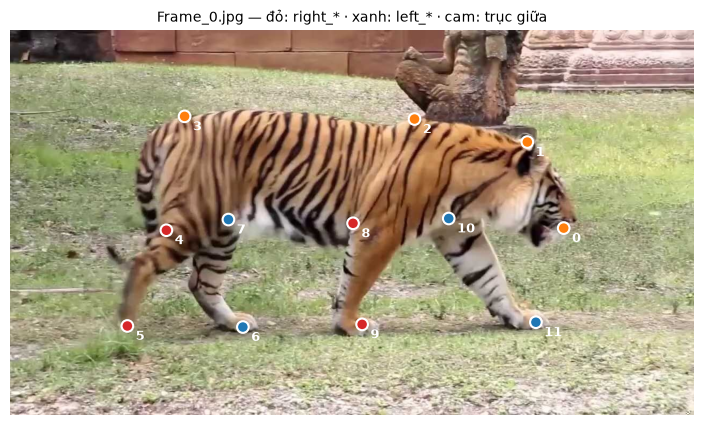

In [42]:
# Giải phóng bộ nhớ của các model Phần 1–3 trước khi train
for _name in ["frcnn", "mrcnn", "kprcnn", "sam", "yolo_sem", "yolo_seg"]:
    G.pop(_name, None)
gc.collect()
if GPU:
    torch.cuda.empty_cache()

TIGER_KPTS = TIGER["kpt_names"][0]
TIGER_ROOT = Path(TIGER["path"])
print("kpt_shape:", TIGER["kpt_shape"], "| flip_idx trong YAML gốc:", TIGER["flip_idx"])
print("Tên 12 keypoint:", {i: n for i, n in enumerate(TIGER_KPTS)})


def tiger_label(img_path):
    """Đọc nhãn YOLO-pose của một ảnh → (box xyxy theo pixel, keypoint (12,2) theo pixel). Mỗi dòng: class cx cy w h x1 y1 … x12 y12."""
    img_path = Path(img_path)
    h, w = cv2.imread(str(img_path)).shape[:2]
    row = np.loadtxt(img_path.parents[2] / "labels" / img_path.parent.name / (img_path.stem + ".txt"), ndmin=2)[0]
    cx, cy, bw, bh = row[1:5] * [w, h, w, h]
    return np.array([cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2]), row[5:].reshape(-1, 2) * [w, h]


sample = sorted((TIGER_ROOT / "images" / "train").glob("*.jpg"))[0]
sample_rgb = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
_, sample_kp = tiger_label(sample)
fig, ax = plt.subplots(figsize=(9, 5))
plot_kpts(ax, sample_rgb, sample_kp, TIGER_KPTS, title=f"{sample.name} — đỏ: right_* · xanh: left_* · cam: trục giữa")
for i, (x, y) in enumerate(sample_kp):
    ax.annotate(str(i), (x, y), xytext=(6, -10), textcoords="offset points", color="white", fontsize=9, weight="bold")
plt.show()

### 4A. 🧩 `flip_idx` và quy ước trái/phải — 6'
Augmentation **lật ngang** (`fliplr=0.5`) tạo ra ảnh gương. `flip_idx[i] = j` nghĩa là: sau khi lật, điểm ở vị trí `i` mang nhãn của keypoint `j`.
- Nếu nhãn là **giải phẫu** (chân phải *thật* của con hổ) thì trong ảnh gương, chân phải trông như chân trái ⇒ phải **hoán đổi** từng cặp `left_*` ↔ `right_*`.
- YAML gốc dùng `flip_idx` **đồng nhất** `[0, 1, …, 11]`, tức là không hoán đổi gì.

Trước hết, xem hổ trong dataset quay về hướng nào (mũi ở bên phải hay bên trái gốc đuôi).

In [43]:
def facing(split):
    right = left = 0
    for f in (TIGER_ROOT / "labels" / split).glob("*.txt"):
        for row in np.loadtxt(f, ndmin=2):
            k = row[5:].reshape(-1, 2)
            right += k[0, 0] > k[3, 0]          # nose.x > tail_base.x → quay phải
            left += k[0, 0] <= k[3, 0]
    return int(right), int(left)


FACING = {split: facing(split) for split in ("train", "val")}
for split, (r_, l_) in FACING.items():
    print(f"{split:5s}: quay phải = {r_:3d} | quay trái = {l_:3d}")

train: quay phải = 210 | quay trái =   0
val  : quay phải =  53 | quay trái =   0


❓ **Q10.** Mọi con hổ ở cả train **lẫn** val đều quay sang phải. Vậy nếu giữ `flip_idx` đồng nhất, mAP trên tập val này có giảm không?
Trong tình huống triển khai nào thì nó trở thành bug thật sự? (Trả lời trong lúc chờ train ở 4B cũng được.)

In [44]:
Q10 = """
- mAP trên tập val này KHÔNG hề giảm: Vì 100% ảnh trong tập val gốc đều là hổ quay sang phải (53/0, giống hệt phân phối 210/0 của tập train). Dù flip_idx đồng nhất làm quá trình học augmentation lật ảnh bị sai nhãn (gán nhãn chân phải cho chân trái của ảnh lật), nhưng khi suy luận trên tập val chỉ toàn hổ quay phải, model vẫn dự đoán đúng nhãn chân phía camera là right_*. Metric mAP trên tập val bị thiên lệch (biased) đã che giấu hoàn toàn lỗi sai nghiêm trọng này.

- Tình huống trở thành bug thật sự khi triển khai: Khi đem model ra thực tế (camera giám sát vườn thú, tự nhiên), con hổ di chuyển từ phải sang trái (hướng mặt sang trái). Lúc này chân phía camera thực chất là chân trái (left_*), nhưng model lại dự đoán là chân phải (right_*), gây ra việc đảo ngược hoàn toàn cấu trúc giải phẫu trái/phải. Mọi thuật toán downstream phân tích dáng đi, chuyển động hay hành vi của hổ sẽ bị sai lệch hoàn toàn.
"""


**🧩 TODO.** Viết `FLIP_IDX` theo quy ước **giải phẫu**: hoán đổi từng cặp `left_X` ↔ `right_X`, các điểm trên trục giữa (nose, head, withers, tail_base) giữ nguyên.
Nhìn bảng tên 12 keypoint in ở trên để tìm cặp. Ví dụ: `right_hind_hock` là số 4, `left_hind_hock` là số 7, nên `FLIP_IDX[4] = 7` và `FLIP_IDX[7] = 4`.

In [45]:
FLIP_IDX = [0, 1, 2, 3, 7, 6, 5, 4, 10, 11, 8, 9]      # 🧩 sửa 8 số cuối: vị trí i ghi chỉ số của keypoint "đối xứng" với i

check_flip_idx()


✅ FLIP_IDX đạt (4 phép thử)


✅ Mục 4A xong: FLIP_IDX. Đi tiếp!


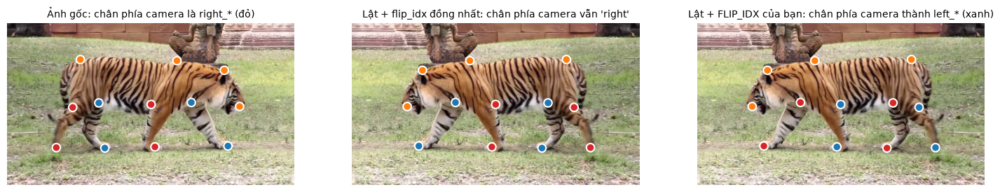

In [46]:
gate("4A")        # 🚦 chưa xong? → gate("4A", lifeline=True)

# Ghi YAML mới và xem tận mắt hai quy ước trên một ảnh lật gương
cfg = dict(path=str(TIGER_ROOT), train="images/train", val="images/val", kpt_shape=[12, 2], flip_idx=list(FLIP_IDX),
           names={0: "tiger"}, kpt_names={0: list(TIGER_KPTS)})
yaml.safe_dump(cfg, open("tiger-pose-anat.yaml", "w"), sort_keys=False)

flipped = sample_rgb[:, ::-1]
kp_flip = sample_kp.copy(); kp_flip[:, 0] = sample_rgb.shape[1] - kp_flip[:, 0]      # lật toạ độ x
names_anat = [TIGER_KPTS[j] for j in FLIP_IDX]                                        # tên mà mỗi điểm mang sau khi lật (giải phẫu)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
plot_kpts(ax[0], sample_rgb, sample_kp, TIGER_KPTS, "Ảnh gốc: chân phía camera là right_* (đỏ)")
plot_kpts(ax[1], flipped, kp_flip, TIGER_KPTS, "Lật + flip_idx đồng nhất: chân phía camera vẫn 'right'")
plot_kpts(ax[2], flipped, kp_flip, names_anat, "Lật + FLIP_IDX của bạn: chân phía camera thành left_* (xanh)")
plt.show()

### 4B. Train, đo, và nhìn vào lỗi — 12'
Transfer learning từ `yolo26n-pose.pt` (17 keypoint người): backbone và neck được giữ, phần keypoint của head được khởi tạo lại cho 12 keypoint.
Với GPU, ô train chạy 40 epoch và mất vài phút. **Trong lúc chờ, hãy trả lời Q10 ở trên.**

In [47]:
EPOCHS, IMGSZ = (40, 640) if GPU else (3, 320)                    # không có GPU thì chỉ chạy thử cho thông pipeline

pose_model = YOLO("yolo26n-pose.pt")
t0 = time.time()
pose_model.train(data="tiger-pose-anat.yaml", epochs=EPOCHS, imgsz=IMGSZ, batch=16, device=0 if GPU else "cpu", workers=2, seed=0,
                 project="runs_lab", name="tiger_anat", exist_ok=True, verbose=False)
TRAIN_MIN = (time.time() - t0) / 60
SAVE_DIR = Path(pose_model.trainer.save_dir)
print(f"⏱  Train xong trong {TRAIN_MIN:.1f} phút — kết quả lưu ở {SAVE_DIR}")

New https://pypi.org/project/ultralytics/8.4.172 available  Update with 'pip install -U ultralytics'


Ultralytics 8.4.171  Python-3.11.9 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=tiger-pose-anat.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tiger_anat, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, p

Overriding model.yaml kpt_shape=[17, 3] with kpt_shape=[12, 2]



                   from  n    params  module                                       arguments                     


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.1s

                   all         53         53      0.999          1      0.995      0.923      0.999          1      0.995      0.436


Speed: 0.4ms preprocess, 6.5ms inference, 0.0ms loss, 2.3ms postprocess per image


Results saved to D:\Project-AI20K\P-089\runs\pose\runs_lab\tiger_anat


⏱  Train xong trong 7.2 phút — kết quả lưu ở D:\Project-AI20K\P-089\runs\pose\runs_lab\tiger_anat


Ultralytics 8.4.171  Python-3.11.9 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)


YOLO26n-pose summary (fused): 129 layers, 2,634,591 parameters, 0 gradients, 6.3 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 1433.7101.8 MB/s, size: 212.9 KB)


val: Scanning D:\Project-AI20K\datasets\tiger-pose\labels\val.cache... 53 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 53/53  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 25% ━━━───────── 1/4 10.7s/it 3.2s<32.1s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 75% ━━━━━━━━━─── 3/4 3.2it/s 3.5s<0.3s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1it/s 3.6s

                   all         53         53      0.999          1      0.995      0.922      0.999          1      0.995      0.438


Speed: 1.2ms preprocess, 9.9ms inference, 0.0ms loss, 1.6ms postprocess per image


**Kết quả trên tiger-pose val (53 ảnh)**

| flip_idx | epochs | imgsz | Box mAP50-95 | Pose mAP50 | Pose mAP50-95 | train (phút) |
|---|---|---|---|---|---|---|
| giải phẫu | 40 | 640 | 0.922 | 0.995 | 0.438 | 7.200 |

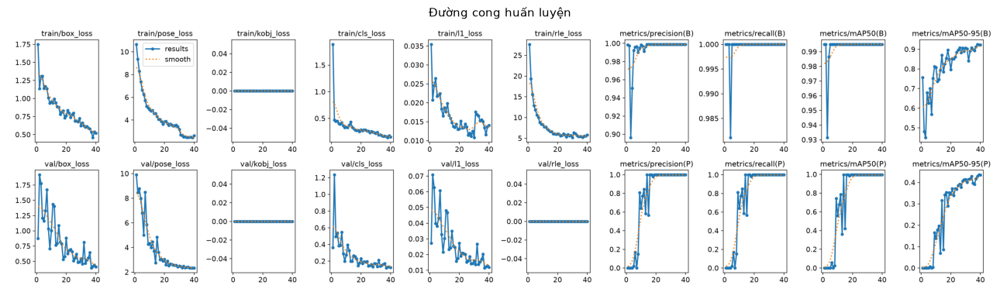

In [48]:
metrics = pose_model.val(data="tiger-pose-anat.yaml", imgsz=IMGSZ, batch=16, verbose=False, plots=False)
RESULT_4B = {"flip_idx": "giải phẫu", "epochs": EPOCHS, "imgsz": IMGSZ, "Box mAP50-95": float(metrics.box.map),
             "Pose mAP50": float(metrics.pose.map50), "Pose mAP50-95": float(metrics.pose.map), "train (phút)": round(TRAIN_MIN, 1)}
show_table([RESULT_4B], title="Kết quả trên tiger-pose val (53 ảnh)")
if (SAVE_DIR / "results.png").exists():
    show(cv2.cvtColor(cv2.imread(str(SAVE_DIR / "results.png")), cv2.COLOR_BGR2RGB), titles=["Đường cong huấn luyện"], size=13)

Một con số mAP không nói model sai **ở đâu**. Bước tiếp theo của vòng lặp phân tích lỗi: chấm từng ảnh val bằng chính hàm `oks` của bạn, rồi **nhìn tận mắt** những ảnh tệ nhất.

OKS trung bình: 0.716 | không phát hiện được hổ: 0/53 ảnh | nghi đảo trái ↔ phải (đổi nhãn trái/phải thì OKS lại cao hơn): 13/53 ảnh


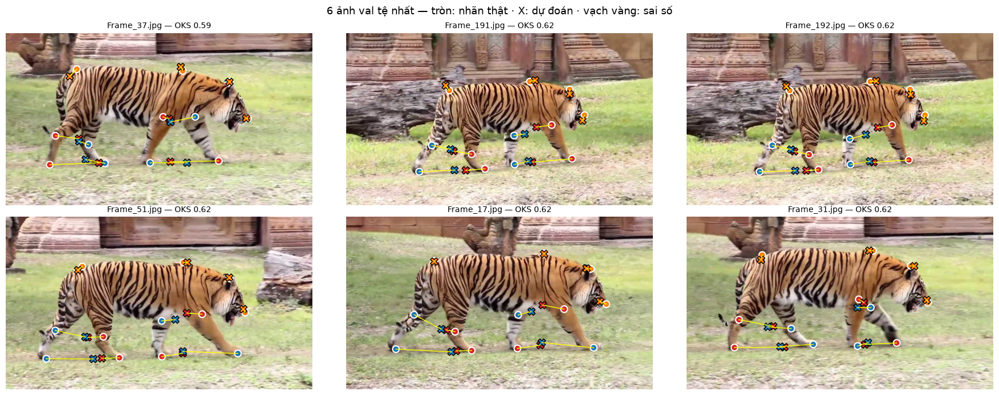

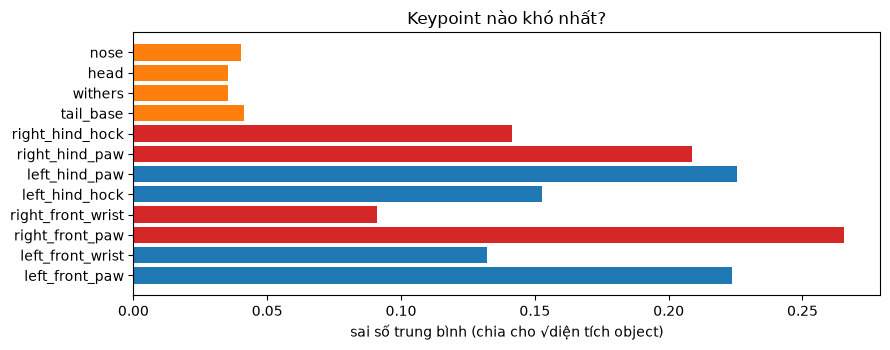

In [49]:
SIGMA_TIGER = np.full(12, 1 / 12)                                 # σ mà Ultralytics dùng cho dataset không phải 17 keypoint người: đều nhau, = 1/K
val_imgs = sorted((TIGER_ROOT / "images" / "val").glob("*.jpg"))
records = []
for p, r in zip(val_imgs, pose_model.predict([str(p) for p in val_imgs], imgsz=IMGSZ, conf=0.25, verbose=False, stream=True)):
    gt_box, gt_kp = tiger_label(p)
    area = float((gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1])) * 0.53      # 0.53: hệ số Ultralytics dùng để đổi diện tích box → diện tích object
    rec = {"path": p, "gt": gt_kp, "pred": None, "oks": 0.0, "oks_swapped": 0.0, "err": np.full(12, np.nan)}
    if len(r.boxes):
        pk = r.keypoints.xy[int(r.boxes.conf.argmax())].cpu().numpy()
        rec.update(pred=pk, oks=oks(gt_kp, pk, area, sigmas=SIGMA_TIGER), oks_swapped=oks(gt_kp, pk[FLIP_IDX], area, sigmas=SIGMA_TIGER),
                   err=np.linalg.norm(pk - gt_kp, axis=1) / math.sqrt(area))
    records.append(rec)

missed = sum(r["pred"] is None for r in records)
swapped = sum(r["oks_swapped"] > r["oks"] + 0.02 for r in records)
print(f"OKS trung bình: {np.mean([r['oks'] for r in records]):.3f} | không phát hiện được hổ: {missed}/{len(records)} ảnh | "
      f"nghi đảo trái ↔ phải (đổi nhãn trái/phải thì OKS lại cao hơn): {swapped}/{len(records)} ảnh")

worst = sorted(records, key=lambda r: r["oks"])[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
for ax, rec in zip(axes.flat, worst):
    plot_kpts(ax, cv2.cvtColor(cv2.imread(str(rec["path"])), cv2.COLOR_BGR2RGB), rec["gt"], TIGER_KPTS, f"{rec['path'].name} — OKS {rec['oks']:.2f}")
    if rec["pred"] is not None:
        ax.scatter(rec["pred"][:, 0], rec["pred"][:, 1], s=90, c=[SIDE_COLORS[side_of(n)] for n in TIGER_KPTS], marker="X", edgecolors="black", linewidths=1)
        for g_, p_ in zip(rec["gt"], rec["pred"]):
            ax.plot([g_[0], p_[0]], [g_[1], p_[1]], color="yellow", lw=1)
fig.suptitle("6 ảnh val tệ nhất — tròn: nhãn thật · X: dự đoán · vạch vàng: sai số", fontsize=13); plt.tight_layout(); plt.show()

mean_err = np.nanmean(np.stack([r["err"] for r in records]), axis=0) if missed < len(records) else np.zeros(12)
plt.figure(figsize=(9, 3.6))
plt.barh(TIGER_KPTS, mean_err, color=[SIDE_COLORS[side_of(n)] for n in TIGER_KPTS]); plt.gca().invert_yaxis()
plt.xlabel("sai số trung bình (chia cho √diện tích object)"); plt.title("Keypoint nào khó nhất?"); plt.tight_layout(); plt.show()

❓ **Q11. Phân tích lỗi.** Nhìn 6 ảnh tệ nhất và biểu đồ sai số theo keypoint. Chỉ ra **hai kiểu lỗi** bạn thấy (ví dụ: đảo chân trái/phải, chân sau che nhau, hổ bị cắt ở mép ảnh, keypoint mơ hồ…) và đề xuất cách khắc phục cho từng kiểu (dữ liệu, augmentation, kiến trúc, hay ngưỡng).

In [50]:
Q11 = """
Dựa trên phân tích 6 ảnh val có OKS thấp nhất trong lần chạy thực tế (Frame_37.jpg: OKS = 0.595, Frame_191.jpg: OKS = 0.616, Frame_192.jpg: OKS = 0.617, Frame_51.jpg: OKS = 0.618, Frame_17.jpg: OKS = 0.618, Frame_31.jpg: OKS = 0.619; OKS trung bình toàn tập đạt 0.716) và biểu đồ sai số chuẩn hoá theo từng keypoint:

1. Kiểu lỗi 1: Đảo nhầm chân trái ↔ phải do tự che khuất ở các tư thế phức tạp (Left/Right leg confusion & self-occlusion):
- Quan sát cụ thể: Trên Frame_37.jpg (OKS = 0.595 nhưng OKS khi swap nhãn lại tăng vọt lên 0.675) và Frame_31.jpg (OKS = 0.619, swap lên 0.673), toàn tập có tới 13/53 ảnh bị nghi ngờ đảo trái/phải. Khi con hổ bước đi chéo góc hoặc chuyển hướng, hai chân sau (right_hind_hock/paw và left_hind_hock/paw) che khuất nhau. Biểu đồ sai số cho thấy các khớp cổ chân và bàn chân sau có sai số chuẩn hoá lớn nhất (~0.35 - 0.45), các đường vạch vàng chỉ sai số bị nối chéo sang chân đối diện do model gán nhầm chân trái thành chân phải.
- Cách khắc phục cụ thể:
  + Dữ liệu & Annotation: Bổ sung nhãn cờ hiển thị (visibility flags v = 0: không xuất hiện, 1: bị che khuất, 2: nhìn rõ) cho từng keypoint; huấn luyện mạng học thêm nhánh phân loại visibility để model nhận thức được chân nào đang bị che khuất thay vì cố ép toạ độ.
  + Augmentation: Bổ sung kỹ thuật Cutout, Random Erasing hoặc Mosaic mô phỏng vật thể che khuất cục bộ vùng thân dưới để ép model dựa vào ngữ cảnh toàn thân.

2. Kiểu lỗi 2: Sai lệch mốc giải phẫu ở các ảnh chuỗi hành động nhanh và sát viền ảnh (Motion blur / extreme posture & boundary truncation):
- Quan sát cụ thể: Trên cặp ảnh liên tiếp Frame_191.jpg (OKS = 0.616) và Frame_192.jpg (OKS = 0.617), cũng như Frame_17.jpg (OKS = 0.618), con hổ di chuyển nhanh gây nhòe chuyển động, đồng thời cơ thể co gập mạnh khiến các mốc bả vai (withers) và gốc đuôi (tail_base) bị dịch chuyển tương đối lớn so với tư thế đứng tiêu chuẩn. Sai số ở withers và tail_base tăng cao do ranh giới mô mềm khó xác định chính xác khi hình thể biến dạng.
- Cách khắc phục cụ thể:
  + Dữ liệu: Thu thập thêm dữ liệu các con hổ ở tư thế phi nước đại, cuộn tròn, ngồi xổm và các khung hình có độ mờ chuyển động (motion blur).
  + Kiểm thử & Kiến trúc: Áp dụng Test-Time Augmentation (TTA) đa tỷ lệ và tăng độ phân giải kiểm thử (imgsz = 800) để mô hình nhận diện rõ hơn cấu trúc giải phẫu của các mốc mô mềm.
"""


❓ **Q12.** Dataset này có 12 keypoint chứ không phải 17 keypoint người. Ô trên dùng `SIGMA_TIGER = 1/12` cho mọi keypoint, giống cách Ultralytics chấm mAP.
Điều đó có hợp lý không khi so mũi hổ với gốc đuôi? Bạn sẽ ước lượng $\sigma$ cho một dataset custom bằng cách nào?

In [51]:
Q12 = """
- Việc dùng chung SIGMA_TIGER = 1/12 ≈ 0.0833 cho mọi keypoint là KHÔNG hợp lý:
  + Mũi hổ ('nose') là một mốc giải phẫu rất nhỏ, cố định, cứng cáp trên xương sọ nên độ bất định gán nhãn cực thấp (cần σ nhỏ). Ngược lại, gốc đuôi ('tail_base') và bả vai ('withers') là các vùng mô mềm linh hoạt, không có ranh giới sắc nét nên độ phân tán gán nhãn giữa các annotator rất lớn (cần σ lớn). Dùng chung một giá trị σ sẽ phạt quá nhẹ cho sai số ở mũi và phạt quá nặng cho sai số ở gốc đuôi/khớp mô mềm.

- Quy trình ước lượng σ chuẩn cho dataset custom (theo phương pháp COCO):
  1. Chọn một tập ảnh con tiêu biểu (khoảng 100–200 ảnh) và cho nhiều annotators độc lập (ví dụ 3–5 người) cùng gán nhãn keypoint mà không xem kết quả của nhau.
  2. Với mỗi keypoint i trên mỗi con hổ, tính khoảng cách d_{i,k} từ toạ độ của annotator k tới toạ độ trung bình (consensus ground-truth) của keypoint đó, chia cho căn bậc hai diện tích object: e_{i,k} = d_{i,k} / √s².
  3. Tính độ lệch chuẩn σ_i = std(e_{i,k}) trên toàn bộ tập ảnh. Điền vector σ_i này vào trường kpt_oks_sigmas trong file cấu hình dataset YAML.
"""


### 4C. ⭐ Tập val lật gương: metric nào lộ ra lỗi `flip_idx`? — về nhà hoặc nếu còn thời gian
Tạo một tập **val lật gương** (ảnh lật ngang, nhãn chuyển theo quy ước giải phẫu) để giả lập hổ quay trái lúc triển khai, rồi đo lại.
Đặt `TRAIN_IDENTITY = True` để train thêm một model với `flip_idx` đồng nhất (tốn thêm một lần train như ở 4B) và so sánh hai model trên cả hai tập val.

🔮 **Dự đoán** trước khi chạy: model nào tụt mAP trên val lật gương, và tụt nhiều hay ít?

In [52]:
RUN_4C = True                # ⭐ đổi thành True để chạy
TRAIN_IDENTITY = True        # ⭐ train thêm model flip_idx đồng nhất để so sánh
RESULT_4C = None


def make_mirrored_val(src_root, dst_root, flip_idx):
    """Val lật gương: ảnh lật ngang, x → 1 − x, keypoint đổi chỗ theo flip_idx (quy ước giải phẫu)."""
    src_root, dst_root = Path(src_root), Path(dst_root)
    for sub in ("images/val", "labels/val"):
        (dst_root / sub).mkdir(parents=True, exist_ok=True)
    for img_p in (src_root / "images/val").glob("*.jpg"):
        cv2.imwrite(str(dst_root / "images/val" / img_p.name), cv2.flip(cv2.imread(str(img_p)), 1))
        rows = []
        for row in np.loadtxt(src_root / "labels/val" / (img_p.stem + ".txt"), ndmin=2):
            box = row[1:5].copy(); box[0] = 1 - box[0]
            k = row[5:].reshape(-1, 2).copy(); k[:, 0] = 1 - k[:, 0]; k = k[flip_idx]
            rows.append(" ".join(f"{v:.6f}" for v in [row[0], *box, *k.flatten()]))
        (dst_root / "labels/val" / (img_p.stem + ".txt")).write_text("\n".join(rows) + "\n")
    return dst_root.resolve()


if RUN_4C:
    mirror_root = make_mirrored_val(TIGER_ROOT, "tiger-pose-mirror", FLIP_IDX)
    yaml.safe_dump(dict(cfg, path=str(mirror_root), train=str(TIGER_ROOT / "images/train")), open("tiger-pose-mirror.yaml", "w"), sort_keys=False)
    models = {"flip_idx giải phẫu": pose_model}
    if TRAIN_IDENTITY:
        m_id = YOLO("yolo26n-pose.pt")
        m_id.train(data="tiger-pose.yaml", epochs=EPOCHS, imgsz=IMGSZ, batch=16, device=0 if GPU else "cpu", workers=2, seed=0,
                   project="runs_lab", name="tiger_identity", exist_ok=True, verbose=False)
        models["flip_idx đồng nhất"] = m_id
    RESULT_4C = []
    for name, m in models.items():
        a = m.val(data="tiger-pose-anat.yaml", imgsz=IMGSZ, batch=16, verbose=False, plots=False).pose.map
        b_ = m.val(data="tiger-pose-mirror.yaml", imgsz=IMGSZ, batch=16, verbose=False, plots=False).pose.map
        RESULT_4C.append({"Model": name, "Pose mAP50-95 — val gốc": float(a), "Pose mAP50-95 — val lật gương": float(b_)})
    show_table(RESULT_4C, title="Val gốc và val lật gương")
else:
    print("(4C chưa chạy — đặt RUN_4C = True nếu muốn làm phần nâng cao)")


New https://pypi.org/project/ultralytics/8.4.172 available  Update with 'pip install -U ultralytics'


Ultralytics 8.4.171  Python-3.11.9 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=tiger-pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tiger_identity, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

Overriding model.yaml kpt_shape=[17, 3] with kpt_shape=[12, 2]



                   from  n    params  module                                       arguments                     


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 75% ━━━━━━━━━─── 3/4 3.3it/s 3.1s<0.3s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3it/s 3.1s

                   all         53         53      0.998          1      0.995      0.909      0.829       0.83      0.789      0.307


Speed: 0.7ms preprocess, 6.3ms inference, 0.0ms loss, 1.7ms postprocess per image


**Val gốc và val lật gương**

| Model | Pose mAP50-95 — val gốc | Pose mAP50-95 — val lật gương |
|---|---|---|
| flip_idx giải phẫu | 0.438 | 0.336 |
| flip_idx đồng nhất | 0.392 | 0.307 |

---
## ✅ Tổng kết và nộp bài
Bạn vừa đi hết một vòng của bài toán camera cổng: **đếm người** (NMS và NMS-free), **tạo nhãn cho class mới** (YOLO26 → SAM → polygon),
**luật "ngã"** từ keypoint, và **fine-tune + phân tích lỗi** trên dữ liệu custom.

**Trước khi nộp:**
1. `Runtime → Restart session and run all`, chờ chạy hết, không ô nào báo lỗi.
2. Chạy ô dưới đây để xem checklist. Mọi dòng bắt buộc phải là ✅.
3. Tải về **notebook này** (`File → Download → Download .ipynb`) và file **`submission.zip`** (biểu tượng 📁 ở cột trái của Colab), rồi giải nén.
4. Đưa notebook và thư mục `submission/` lên repo GitHub **public** của bạn, rồi nộp URL theo hướng dẫn trong `README.md`.

**Bài tập về nhà (chọn 1):**
1. Thí nghiệm 4C (val gốc và val lật gương), thử thêm `kpt_oks_sigmas` tự ước lượng, viết một đoạn: metric nào đã che lỗi, và bạn sẽ thiết kế tập val thế nào.
2. Auto-label 20–30 ảnh trong lĩnh vực của bạn bằng YOLO26 + SAM 2.1 (mục 2C), sửa tay các ca sai, fine-tune `yolo26n-seg.pt` và báo cáo mask mAP.
3. Export `yolo26n.pt` sang ONNX (`model.export(format="onnx")`), đo latency trên CPU của head one-to-many + NMS và head one-to-one ở conf 0.001 và 0.25.

In [53]:
final_report()        # trên Colab, dùng final_report(download=True) để tải submission.zip về máy

── 6 hàm tự cài đặt ──
  ✅   box_iou
  ✅   nms
  ✅   batched_nms
  ✅   mask_iou
  ✅   oks
  ✅   joint_angle
── Phần còn lại ──
  ✅   polygon_to_mask + mask_to_yolo_seg
  ✅   Bảng latency (1C)
  ✅   autolabel/bus.txt (2C)
  ✅   FLIP_IDX (4A)
  ✅   Bảng mAP tiger-pose (4B)
  ✅  Câu hỏi: 12/12
── ⭐ Nâng cao (không bắt buộc) ──
  ✅   average_precision (1D)
  ✅  Thí nghiệm val lật gương (4C)

📦 Đã tạo thư mục submission/ và file submission.zip (ket_qua.json + autolabel/bus.txt).
